In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA,FastICA
from sklearn.manifold import TSNE
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, balanced_accuracy_score

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
# from sklearn.inspection import permutation_importance, DecisionBoundaryDisplay
from sklearn.model_selection import KFold #, train_test_split, cross_validate, StratifiedKFold, StratifiedShuffleSplit

from xgboost import XGBClassifier


import tensorflow as tf
tf.keras.utils.set_random_seed(42)

import warnings
warnings.filterwarnings("ignore")

# Data Reading

In [2]:
rri_data = pd.read_excel('clean_ppd_feature_output.xlsx')
slp_data = pd.read_excel('clean_ppd_slpallfeature_output.xlsx')
act_data = pd.read_excel('clean_ppd_actallfeature_output.xlsx')

In [3]:
rri_col = ['mnn','sdnn','minmax','dminmax','cvnn','rmssd','sdsd','nn50','pnn50','nn20','pnn20',
           'tinn_n','tinn_m','tinn','tri_index',
           'vlfpk','lfpk','hfpk','vlfabs','lfabs','hfabs','vlfrel','lfrel','hfrel','vlflog','lflog','hflog','lfnorm','hfnorm','lfhf','ttp',
           'sd1','sd2','S','sd1sd2','se','dfalong','dfashort']
slp_col = ['light-sleep','deep-sleep','dream','wake','total-sleep','day-sleep','sneez','sleep-score','sleep-segment',
           'ls-ratio','ds-ratio','dr-ratio','wk-ratio','dy-ratio']
act_col = ['step','distance','calories','step-per-dis','cal-per-step','cal-per-dis']
msg_col = ['day','sub']

In [4]:
rri_ft = rri_data[rri_col]
slp_ft = slp_data[slp_col]
act_ft = act_data[act_col]
msg_ft = rri_data[msg_col]

ppd_flg = rri_data['ppd']
ppd_flg[ppd_flg == 'Control'] = 0
ppd_flg[ppd_flg == 'Abnormal'] = 1

ftmtrix = np.hstack((rri_ft.to_numpy(),
                     slp_ft.to_numpy(),
                     np.log1p(act_ft.to_numpy()),
                     msg_ft.to_numpy(),
                     ppd_flg.to_numpy(dtype=int).reshape(len(ppd_flg),1)))


# Normalization

In [5]:
allfeature_idx = 58

hrvdim = 38
slpdim = 14
actdim = 6

kfcv_max = np.max(ftmtrix[:,:allfeature_idx],axis=0)
kfcv_min = np.min(ftmtrix[:,:allfeature_idx],axis=0)
nm_kfcv = (ftmtrix[:,:allfeature_idx]-kfcv_min)/(kfcv_max-kfcv_min)

# Visualization

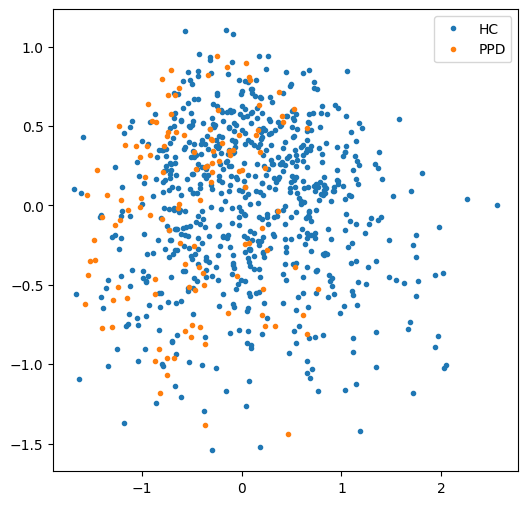

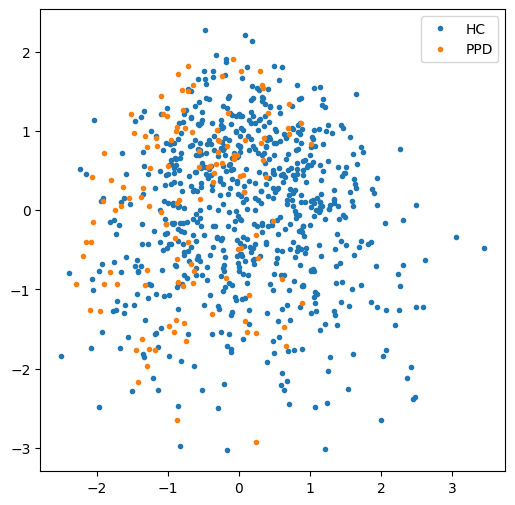

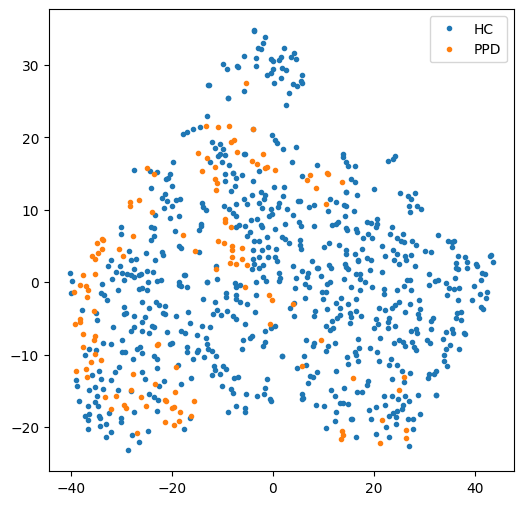

In [6]:
pca = PCA(n_components=2, random_state=42)
Xt = pca.fit_transform(nm_kfcv)
plt.figure(figsize=(6,6))
plt.plot(Xt[ftmtrix[:,-1]==0,0],Xt[ftmtrix[:,-1]==0,1],'.')
plt.plot(Xt[ftmtrix[:,-1]==1,0],Xt[ftmtrix[:,-1]==1,1],'.')
plt.legend(['HC','PPD'])

ica = FastICA(n_components=2, random_state=42)
Xtica = ica.fit_transform(nm_kfcv)
plt.figure(figsize=(6,6))
plt.plot(Xtica[ftmtrix[:,-1]==0,0],Xtica[ftmtrix[:,-1]==0,1],'.')
plt.plot(Xtica[ftmtrix[:,-1]==1,0],Xtica[ftmtrix[:,-1]==1,1],'.')
plt.legend(['HC','PPD'])

tsne = TSNE(n_components=2,random_state=42)
Xttsne = tsne.fit_transform(nm_kfcv)
plt.figure(figsize=(6,6))
plt.plot(Xttsne[ftmtrix[:,-1]==0,0],Xttsne[ftmtrix[:,-1]==0,1],'.')
plt.plot(Xttsne[ftmtrix[:,-1]==1,0],Xttsne[ftmtrix[:,-1]==1,1],'.')
plt.legend(['HC','PPD'])


# Subject Independent Classification

## HRV modality

In [7]:
def hrvcls(dim=38) :
    inlyr = tf.keras.Input((dim,))
    fc1 = tf.keras.layers.Dense(units=32,activation='relu',name='hrv_fc1')(inlyr)
    fc2 = tf.keras.layers.Dense(units=16,activation='relu',name='hrv_fc2')(fc1)
    fc3 = tf.keras.layers.Dense(units=8,activation='relu',name='hrv_fc3')(fc2)
    fc4 = tf.keras.layers.Dense(units=4,activation='relu',name='hrv_fc4')(fc3)
    fco = tf.keras.layers.Dense(units=2,activation='softmax',bias_initializer=tf.keras.initializers.Constant([0.5,0.5]),name='hrv_fco')(fc4)

    hrvmd = tf.keras.Model(inputs=inlyr,outputs=fco,name='hrvmd')

    return hrvmd

## Sleep modality

In [8]:
def slpcls(dim=14) :
    inlyr = tf.keras.Input((dim,))
    fc1 = tf.keras.layers.Dense(units=16,activation='relu',name='slp_fc1')(inlyr)
    fc2 = tf.keras.layers.Dense(units=8,activation='relu',name='slp_fc2')(fc1)
    fc3 = tf.keras.layers.Dense(units=4,activation='relu',name='slp_fc3')(fc2)
    fco = tf.keras.layers.Dense(units=2,activation='softmax',bias_initializer=tf.keras.initializers.Constant([0.45,0.55]),name='slp_fco')(fc3)

    slpmd = tf.keras.Model(inputs=inlyr,outputs=fco,name='slpmd')

    return slpmd

## Activity modality

In [9]:
def actcls(dim=6) :
    inlyr = tf.keras.Input((dim,))
    fc1 = tf.keras.layers.Dense(units=8,activation='relu',name='act_fc1')(inlyr)
    fc2 = tf.keras.layers.Dense(units=4,activation='relu',name='act_fc2')(fc1)
    fco = tf.keras.layers.Dense(units=2,activation='softmax',bias_initializer=tf.keras.initializers.Constant([0.45,0.55]),name='act_fco')(fc2)

    actmd = tf.keras.Model(inputs=inlyr,outputs=fco,name='actmd')

    return actmd

## HRV model training

sub 5 : acc = 0.3333, in fold 44
sub 6 : acc = 0.3333, in fold 53
sub 8 : acc = 0.7143, in fold 39
sub 9 : acc = 0.425, in fold 32
sub 16 : acc = 0.6316, in fold 44
sub 18 : acc = 0.0, in fold 14
sub 20 : acc = 0.8, in fold 40
sub 24 : acc = 0.5833, in fold 33
sub 25 : acc = 1.0, in fold 37
sub 28 : acc = 0.9706, in fold 33
sub 29 : acc = 0.0, in fold 38
sub 30 : acc = 0.72, in fold 32
sub 32 : acc = 1.0, in fold 51
sub 33 : acc = 0.0513, in fold 29
sub 35 : acc = 0.5, in fold 50
sub 37 : acc = 1.0, in fold 25
sub 41 : acc = 0.4375, in fold 44
sub 42 : acc = 0.6571, in fold 38
sub 44 : acc = 0.2703, in fold 52
sub 53 : acc = 0.7333, in fold 35
sub 55 : acc = 0.8333, in fold 26
sub 58 : acc = 0.0, in fold 52
sub 60 : acc = 0.4615, in fold 49
sub 63 : acc = 0.0, in fold 33
sub 66 : acc = 0.0, in fold 48
sub 67 : acc = 0.8378, in fold 22
sub 69 : acc = 0.7407, in fold 26
sub 70 : acc = 0.825, in fold 43
sub 72 : acc = 0.3939, in fold 44
sub 75 : acc = 0.92, in fold 41
sub 80 : acc = 0.333

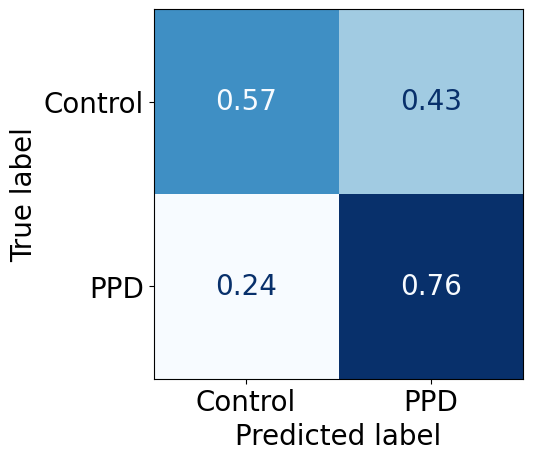

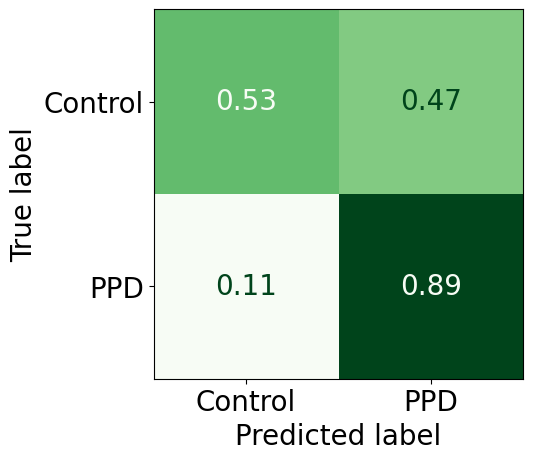

In [87]:
# HRV
tf.keras.utils.set_random_seed(42)
sgkf = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=42)

tt_res = np.array([])
tt_y = np.array([])
tt_subres = np.array([])
tt_suby = np.array([])

for sub in np.array([5,6,8,9,
                     16,18,
                     20,24,25,28,29,
                     30,32,33,35,37,
                     41,42,44,
                     53,55,58,
                     60,63,66,67,69,
                     70,72,75,
                     80,81,85,
                     90,91,92,93,95,98,99,
                     104]) :
    
    tr_x = nm_kfcv[ftmtrix[:,-2]!=sub,:38]
    tr_y = ftmtrix[ftmtrix[:,-2]!=sub,-1]
    tst_x = nm_kfcv[ftmtrix[:,-2]==sub,:38]
    tst_y = ftmtrix[ftmtrix[:,-2]==sub,-1]
    tt_y = np.append(tt_y,tst_y)
    tt_suby = np.append(tt_suby,tst_y[0])

    spw = compute_sample_weight(class_weight="balanced",y=tr_y)

    ytronehot = tf.keras.utils.to_categorical(y=tr_y,num_classes=2)
    ytsonehot = tf.keras.utils.to_categorical(y=tst_y,num_classes=2)

    val_results = np.array([])
    for i, (train_index, test_index) in enumerate(sgkf.split(tr_x, tr_y, ftmtrix[ftmtrix[:,-2]!=sub,-2])):
        xtr,ytroh = tr_x[train_index,:], ytronehot[train_index,:]
        xcv,ycvoh = tr_x[test_index,:], ytronehot[test_index,:]
        spw_tr = compute_sample_weight(class_weight="balanced",y=tr_y[train_index])
        spw_cv = compute_sample_weight(class_weight="balanced",y=tr_y[test_index])

        tf.keras.backend.clear_session()
        tstmd = hrvcls()
        subopt = tf.keras.optimizers.AdamW(learning_rate=5e-4,clipnorm=1.0)
        tstmd.compile(optimizer=subopt,loss=tf.keras.losses.CategoricalFocalCrossentropy(alpha=[0.475,0.525]),#tf.keras.losses.CategoricalFocalCrossentropy(alpha=[0.475,0.525]),
                      metrics=['categorical_accuracy',tf.keras.metrics.F1Score(average='macro')],
                      weighted_metrics=['categorical_accuracy'])
        his = tstmd.fit(x=xtr,y=ytroh,
                        batch_size=256,epochs=100,verbose=0,sample_weight=spw_tr,
                        validation_data=(xcv,ycvoh,spw_cv),validation_batch_size=256)
        val_acc = his.history['val_weighted_categorical_accuracy']
        epc = np.argmax(val_acc)+1
        val_results = np.append(val_results,epc)

    avg_epc = round(np.mean(val_results))
    tf.keras.backend.clear_session()
    submd = hrvcls()
    subopt = tf.keras.optimizers.AdamW(learning_rate=5e-4,clipnorm=1.0)
    submd.compile(optimizer=subopt,loss=tf.keras.losses.CategoricalFocalCrossentropy(alpha=[0.475,0.525]),
                  metrics=['categorical_accuracy'])
    his = submd.fit(x=tr_x,y=ytronehot,
                    batch_size=256,epochs=avg_epc,verbose=0,sample_weight=spw,
                    validation_data=(tst_x,ytsonehot),validation_batch_size=256)
    submd.save(f'multimodel_sub_ann_res/kfold/ann_ppd_hrv_sub{sub}.validbest.h5')
    ann_res = submd.predict(tst_x,batch_size=256,verbose=0)
    print(f"sub {sub} : acc = {round(accuracy_score(tst_y, ann_res.argmax(axis=1)),4)}, in fold {avg_epc}" )
    tt_res = np.append(tt_res,ann_res.argmax(axis=1))
    if round(accuracy_score(tst_y, ann_res.argmax(axis=1)),4) >= 0.5 :
        tt_subres = np.append(tt_subres,tst_y[0])
    else:
        tt_subres = np.append(tt_subres,1-tst_y[0])

print(f"Macro-Avg : acc = {round(accuracy_score(tt_y, tt_res),4)}, balance_acc = {round(balanced_accuracy_score(tt_y, tt_res),4)}, Mf1 = {round(f1_score(tt_y, tt_res, average='macro'),4)}, AUC = {round(roc_auc_score(tt_y, tt_res),4)}" )
plt.rcParams.update({'font.size': 20})
cm3av2 = confusion_matrix(tt_y, tt_res,normalize='true')
cm_display3av2 = ConfusionMatrixDisplay(cm3av2,display_labels=['Control','PPD']).plot(cmap='Blues',colorbar=False)

print(f"Macro-Avg : acc = {round(accuracy_score(tt_suby, tt_subres),4)}, balance_acc = {round(balanced_accuracy_score(tt_suby, tt_subres),4)}, Mf1 = {round(f1_score(tt_suby, tt_subres, average='macro'),4)}, AUC = {round(roc_auc_score(tt_suby, tt_subres),4)}" )
plt.rcParams.update({'font.size': 20})
cm3av2 = confusion_matrix(tt_suby, tt_subres,normalize='true')
cm_display3av2 = ConfusionMatrixDisplay(cm3av2,display_labels=['Control','PPD']).plot(cmap='Greens',colorbar=False)

## Sleep model training

sub 5 : acc = 0.1111, in fold 59
sub 6 : acc = 0.25, in fold 66
sub 8 : acc = 0.8571, in fold 43
sub 9 : acc = 0.0, in fold 60
sub 16 : acc = 0.1579, in fold 53
sub 18 : acc = 1.0, in fold 51
sub 20 : acc = 0.8, in fold 40
sub 24 : acc = 1.0, in fold 38
sub 25 : acc = 1.0, in fold 62
sub 28 : acc = 0.6765, in fold 67
sub 29 : acc = 0.6667, in fold 43
sub 30 : acc = 0.6, in fold 62
sub 32 : acc = 0.0, in fold 54
sub 33 : acc = 0.8974, in fold 51
sub 35 : acc = 1.0, in fold 53
sub 37 : acc = 0.0, in fold 63
sub 41 : acc = 0.3125, in fold 39
sub 42 : acc = 0.8, in fold 45
sub 44 : acc = 0.3784, in fold 58
sub 53 : acc = 0.9333, in fold 51
sub 55 : acc = 0.7778, in fold 60
sub 58 : acc = 0.0, in fold 51
sub 60 : acc = 0.0, in fold 36
sub 63 : acc = 0.6667, in fold 50
sub 66 : acc = 0.0, in fold 52
sub 67 : acc = 0.8919, in fold 66
sub 69 : acc = 0.7037, in fold 67
sub 70 : acc = 0.95, in fold 61
sub 72 : acc = 0.3939, in fold 56
sub 75 : acc = 0.56, in fold 56
sub 80 : acc = 0.6296, in fol

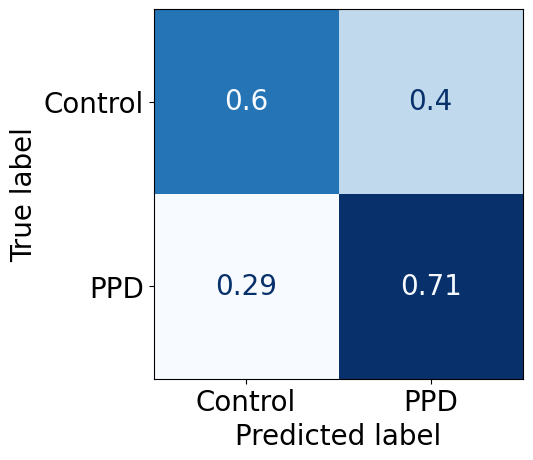

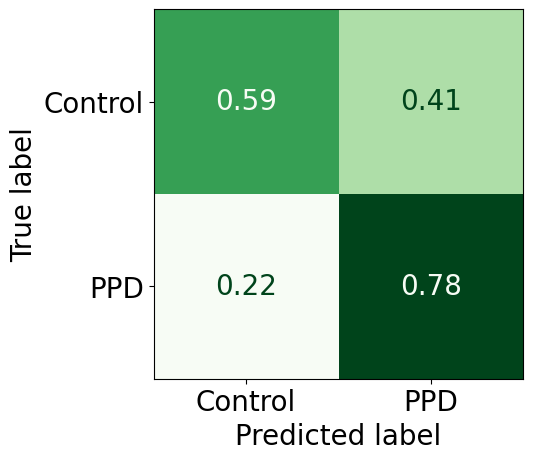

In [83]:
# HRV
tf.keras.utils.set_random_seed(42)
sgkf = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=42)

tt_res = np.array([])
tt_y = np.array([])
tt_subres = np.array([])
tt_suby = np.array([])

for sub in np.array([5,6,8,9,
                     16,18,
                     20,24,25,28,29,
                     30,32,33,35,37,
                     41,42,44,
                     53,55,58,
                     60,63,66,67,69,
                     70,72,75,
                     80,81,85,
                     90,91,92,93,95,98,99,
                     104]) :
    
    tr_x = nm_kfcv[ftmtrix[:,-2]!=sub,38:38+14]
    tr_y = ftmtrix[ftmtrix[:,-2]!=sub,-1]
    tst_x = nm_kfcv[ftmtrix[:,-2]==sub,38:38+14]
    tst_y = ftmtrix[ftmtrix[:,-2]==sub,-1]
    tt_y = np.append(tt_y,tst_y)
    tt_suby = np.append(tt_suby,tst_y[0])

    spw = compute_sample_weight(class_weight="balanced",y=tr_y)

    ytronehot = tf.keras.utils.to_categorical(y=tr_y,num_classes=2)
    ytsonehot = tf.keras.utils.to_categorical(y=tst_y,num_classes=2)

    val_results = np.array([])
    for i, (train_index, test_index) in enumerate(sgkf.split(tr_x, tr_y, ftmtrix[ftmtrix[:,-2]!=sub,-2])):
        xtr,ytroh = tr_x[train_index,:], ytronehot[train_index,:]
        xcv,ycvoh = tr_x[test_index,:], ytronehot[test_index,:]
        spw_tr = compute_sample_weight(class_weight="balanced",y=tr_y[train_index])
        spw_cv = compute_sample_weight(class_weight="balanced",y=tr_y[test_index])

        tf.keras.backend.clear_session()
        tstmd = slpcls()
        subopt = tf.keras.optimizers.AdamW(learning_rate=5e-4,clipnorm=1.0)
        tstmd.compile(optimizer=subopt,loss=tf.keras.losses.CategoricalCrossentropy(),#tf.keras.losses.CategoricalFocalCrossentropy(alpha=[0.5,0.5],gamma=1.5),
                      metrics=['categorical_accuracy',tf.keras.metrics.F1Score(average='macro')],
                      weighted_metrics=['categorical_accuracy'])
        his = tstmd.fit(x=xtr,y=ytroh,
                        batch_size=256,epochs=100,verbose=0,sample_weight=spw_tr,
                        validation_data=(xcv,ycvoh,spw_cv),validation_batch_size=256)
        val_acc = his.history['val_weighted_categorical_accuracy']
        epc = np.argmax(val_acc)+1
        val_results = np.append(val_results,epc)

    avg_epc = round(np.mean(val_results))
    tf.keras.backend.clear_session()
    submd = slpcls()
    subopt = tf.keras.optimizers.AdamW(learning_rate=5e-4,clipnorm=1.0)
    submd.compile(optimizer=subopt,loss=tf.keras.losses.CategoricalCrossentropy(),#tf.keras.losses.CategoricalFocalCrossentropy(alpha=[0.5,0.5],gamma=1.5),
                  metrics=['categorical_accuracy'])
    his = submd.fit(x=tr_x,y=ytronehot,
                    batch_size=256,epochs=avg_epc,verbose=0,sample_weight=spw,
                    validation_data=(tst_x,ytsonehot),validation_batch_size=256)
    submd.save(f'multimodel_sub_ann_res/kfold/ann_ppd_slp_sub{sub}.validbest.h5')
    ann_res = submd.predict(tst_x,batch_size=256,verbose=0)
    print(f"sub {sub} : acc = {round(accuracy_score(tst_y, ann_res.argmax(axis=1)),4)}, in fold {avg_epc}" )
    tt_res = np.append(tt_res,ann_res.argmax(axis=1))
    if round(accuracy_score(tst_y, ann_res.argmax(axis=1)),4) >= 0.5 :
        tt_subres = np.append(tt_subres,tst_y[0])
    else:
        tt_subres = np.append(tt_subres,1-tst_y[0])

print(f"Macro-Avg : acc = {round(accuracy_score(tt_y, tt_res),4)}, balance_acc = {round(balanced_accuracy_score(tt_y, tt_res),4)}, Mf1 = {round(f1_score(tt_y, tt_res, average='macro'),4)}, AUC = {round(roc_auc_score(tt_y, tt_res),4)}" )
plt.rcParams.update({'font.size': 20})
cm3av2 = confusion_matrix(tt_y, tt_res,normalize='true')
cm_display3av2 = ConfusionMatrixDisplay(cm3av2,display_labels=['Control','PPD']).plot(cmap='Blues',colorbar=False)

print(f"Macro-Avg : acc = {round(accuracy_score(tt_suby, tt_subres),4)}, balance_acc = {round(balanced_accuracy_score(tt_suby, tt_subres),4)}, Mf1 = {round(f1_score(tt_suby, tt_subres, average='macro'),4)}, AUC = {round(roc_auc_score(tt_suby, tt_subres),4)}" )
plt.rcParams.update({'font.size': 20})
cm3av2 = confusion_matrix(tt_suby, tt_subres,normalize='true')
cm_display3av2 = ConfusionMatrixDisplay(cm3av2,display_labels=['Control','PPD']).plot(cmap='Greens',colorbar=False)

## Activity model training

sub 5 : acc = 0.3889 in fold 35
sub 6 : acc = 1.0 in fold 50
sub 8 : acc = 1.0 in fold 59
sub 9 : acc = 0.95 in fold 58
sub 16 : acc = 0.7368 in fold 57
sub 18 : acc = 0.6667 in fold 47
sub 20 : acc = 1.0 in fold 19
sub 24 : acc = 1.0 in fold 47
sub 25 : acc = 1.0 in fold 68
sub 28 : acc = 0.8529 in fold 32
sub 29 : acc = 0.5 in fold 65
sub 30 : acc = 1.0 in fold 72
sub 32 : acc = 0.0 in fold 49
sub 33 : acc = 0.9744 in fold 49
sub 35 : acc = 1.0 in fold 70
sub 37 : acc = 0.7273 in fold 21
sub 41 : acc = 0.9375 in fold 48
sub 42 : acc = 0.1143 in fold 47
sub 44 : acc = 0.0 in fold 45
sub 53 : acc = 0.0 in fold 53
sub 55 : acc = 1.0 in fold 48
sub 58 : acc = 1.0 in fold 54
sub 60 : acc = 0.8462 in fold 54
sub 63 : acc = 0.6667 in fold 42
sub 66 : acc = 0.5 in fold 41
sub 67 : acc = 0.0 in fold 59
sub 69 : acc = 0.0 in fold 57
sub 70 : acc = 0.0 in fold 43
sub 72 : acc = 1.0 in fold 42
sub 75 : acc = 0.0 in fold 60
sub 80 : acc = 0.3333 in fold 46
sub 81 : acc = 0.8462 in fold 56
sub 85 

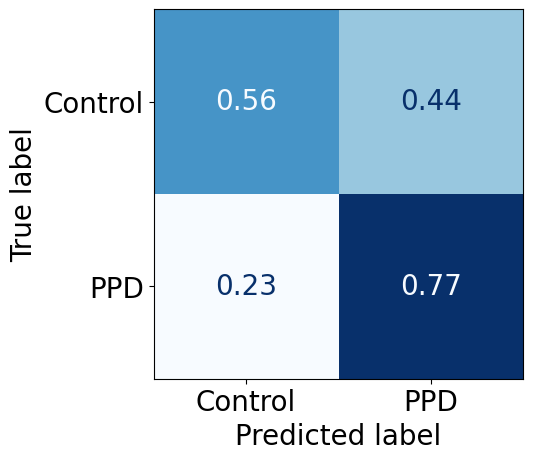

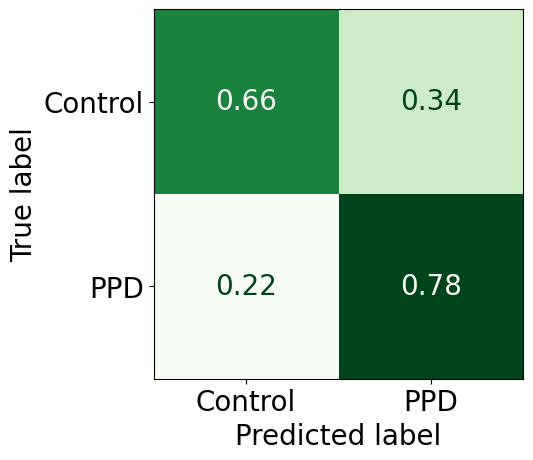

In [64]:
# HRV
tf.keras.utils.set_random_seed(42)
sgkf = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=42)

tt_res = np.array([])
tt_y = np.array([])
tt_subres = np.array([])
tt_suby = np.array([])

for sub in np.array([5,6,8,9,
                     16,18,
                     20,24,25,28,29,
                     30,32,33,35,37,
                     41,42,44,
                     53,55,58,
                     60,63,66,67,69,
                     70,72,75,
                     80,81,85,
                     90,91,92,93,95,98,99,
                     104]) :
    
    tr_x = nm_kfcv[ftmtrix[:,-2]!=sub,38+14:]
    tr_y = ftmtrix[ftmtrix[:,-2]!=sub,-1]
    tst_x = nm_kfcv[ftmtrix[:,-2]==sub,38+14:38+14+6]
    tst_y = ftmtrix[ftmtrix[:,-2]==sub,-1]
    tt_y = np.append(tt_y,tst_y)
    tt_suby = np.append(tt_suby,tst_y[0])

    spw = compute_sample_weight(class_weight="balanced",y=tr_y)

    ytronehot = tf.keras.utils.to_categorical(y=tr_y,num_classes=2)
    ytsonehot = tf.keras.utils.to_categorical(y=tst_y,num_classes=2)

    val_results = np.array([])
    for i, (train_index, test_index) in enumerate(sgkf.split(tr_x, tr_y, ftmtrix[ftmtrix[:,-2]!=sub,-2])):
        xtr,ytroh = tr_x[train_index,:], ytronehot[train_index,:]
        xcv,ycvoh = tr_x[test_index,:], ytronehot[test_index,:]
        spw_tr = compute_sample_weight(class_weight="balanced",y=tr_y[train_index])
        spw_cv = compute_sample_weight(class_weight="balanced",y=tr_y[test_index])

        tf.keras.backend.clear_session()
        tstmd = actcls()
        subopt = tf.keras.optimizers.AdamW(learning_rate=5e-4,clipnorm=1.0)
        tstmd.compile(optimizer=subopt,loss=tf.keras.losses.CategoricalCrossentropy(),
                      metrics=['categorical_accuracy',tf.keras.metrics.F1Score(average='macro')],
                      weighted_metrics=['categorical_accuracy'])
        his = tstmd.fit(x=xtr,y=ytroh,
                        batch_size=256,epochs=100,verbose=0,sample_weight=spw_tr,
                        validation_data=(xcv,ycvoh,spw_cv),validation_batch_size=256)
        val_acc = his.history['val_weighted_categorical_accuracy']
        epc = np.argmax(val_acc)+1
        val_results = np.append(val_results,epc)

    avg_epc = round(np.mean(val_results))
    tf.keras.backend.clear_session()
    submd = actcls()
    subopt = tf.keras.optimizers.AdamW(learning_rate=5e-4,clipnorm=1.0)
    submd.compile(optimizer=subopt,loss=tf.keras.losses.CategoricalCrossentropy(),
                  metrics=['categorical_accuracy'])
    his = submd.fit(x=tr_x,y=ytronehot,
                    batch_size=256,epochs=avg_epc,verbose=0,sample_weight=spw,
                    validation_data=(tst_x,ytsonehot),validation_batch_size=256)
    submd.save(f'multimodel_sub_ann_res/kfold/ann_ppd_act_sub{sub}.validbest.h5')
    ann_res = submd.predict(tst_x,batch_size=256,verbose=0)
    print(f"sub {sub} : acc = {round(accuracy_score(tst_y, ann_res.argmax(axis=1)),4)} in fold {avg_epc}" )
    tt_res = np.append(tt_res,ann_res.argmax(axis=1))
    if round(accuracy_score(tst_y, ann_res.argmax(axis=1)),4) >= 0.5 :
        tt_subres = np.append(tt_subres,tst_y[0])
    else:
        tt_subres = np.append(tt_subres,1-tst_y[0])

print(f"Macro-Avg : acc = {round(accuracy_score(tt_y, tt_res),4)}, balance_acc = {round(balanced_accuracy_score(tt_y, tt_res),4)}, Mf1 = {round(f1_score(tt_y, tt_res, average='macro'),4)}, AUC = {round(roc_auc_score(tt_y, tt_res),4)}" )
plt.rcParams.update({'font.size': 20})
cm3av2 = confusion_matrix(tt_y, tt_res,normalize='true')
cm_display3av2 = ConfusionMatrixDisplay(cm3av2,display_labels=['Control','PPD']).plot(cmap='Blues',colorbar=False)

print(f"Macro-Avg : acc = {round(accuracy_score(tt_suby, tt_subres),4)}, balance_acc = {round(balanced_accuracy_score(tt_suby, tt_subres),4)}, Mf1 = {round(f1_score(tt_suby, tt_subres, average='macro'),4)}, AUC = {round(roc_auc_score(tt_suby, tt_subres),4)}" )
plt.rcParams.update({'font.size': 20})
cm3av2 = confusion_matrix(tt_suby, tt_subres,normalize='true')
cm_display3av2 = ConfusionMatrixDisplay(cm3av2,display_labels=['Control','PPD']).plot(cmap='Greens',colorbar=False)

## Dense MoE

In [10]:
def ppd_class_model(hrv_md:tf.keras.Model,slp_md:tf.keras.Model,act_md:tf.keras.Model,bias_ini=[0.45,0.55]) :
    hrv_md.trainable = False
    slp_md.trainable = False
    act_md.trainable = False

    hrvlaten = hrv_md.get_layer("hrv_fc4").output
    slplaten = slp_md.get_layer("slp_fc3").output
    actlaten = act_md.get_layer("act_fc2").output

    multimd_cc = tf.keras.layers.Concatenate(name='multimd_cc')([hrv_md.input,slp_md.input,act_md.input])
    
    multimd_fc1 = tf.keras.layers.Dense(units=12,activation='relu',name='multimd_fc1')(multimd_cc)
    multimd_fc2 = tf.keras.layers.Dense(units=6,activation='relu',name='multimd_fc2')(multimd_fc1)
    multimd_fc3 = tf.keras.layers.Dense(units=3,activation='softmax',name='multimd_fc3')(multimd_fc2)
    # multimd_fc4 = tf.keras.layers.Dense(units=4,activation='relu',name='multimd_fc4')(multimd_fc3)
    # multimd_fco = tf.keras.layers.Dense(units=2,activation='softmax',bias_initializer=tf.keras.initializers.Constant([0.4,0.6]),name='multimd_fco')(multimd_fc4) 

    hrvmult = tf.keras.layers.Multiply(name="hrvmult")([hrvlaten,multimd_fc3[:,0]])
    slpmult = tf.keras.layers.Multiply(name="slpmult")([slplaten,multimd_fc3[:,1]])
    actmult = tf.keras.layers.Multiply(name="actmult")([actlaten,multimd_fc3[:,2]])
    dission = tf.keras.layers.Add(name="dission")([hrvmult,slpmult,actmult])

    cls = tf.keras.layers.Dense(units=2,activation="softmax",bias_initializer=tf.keras.initializers.Constant(bias_ini),name="cls")(dission)
    # cls = tf.keras.layers.Activation(activation='softmax',name="cls")(dission)

    ppdmd = tf.keras.Model(inputs=[hrv_md.input,slp_md.input,act_md.input],outputs=cls,name="ppdmd")

    return ppdmd

Model: "ppdmd"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_13 (InputLayer)       [(None, 38)]                 0         []                            
                                                                                                  
 input_14 (InputLayer)       [(None, 14)]                 0         []                            
                                                                                                  
 input_15 (InputLayer)       [(None, 6)]                  0         []                            
                                                                                                  
 multimd_cc (Concatenate)    (None, 58)                   0         ['input_13[0][0]',            
                                                                     'input_14[0][0]',        

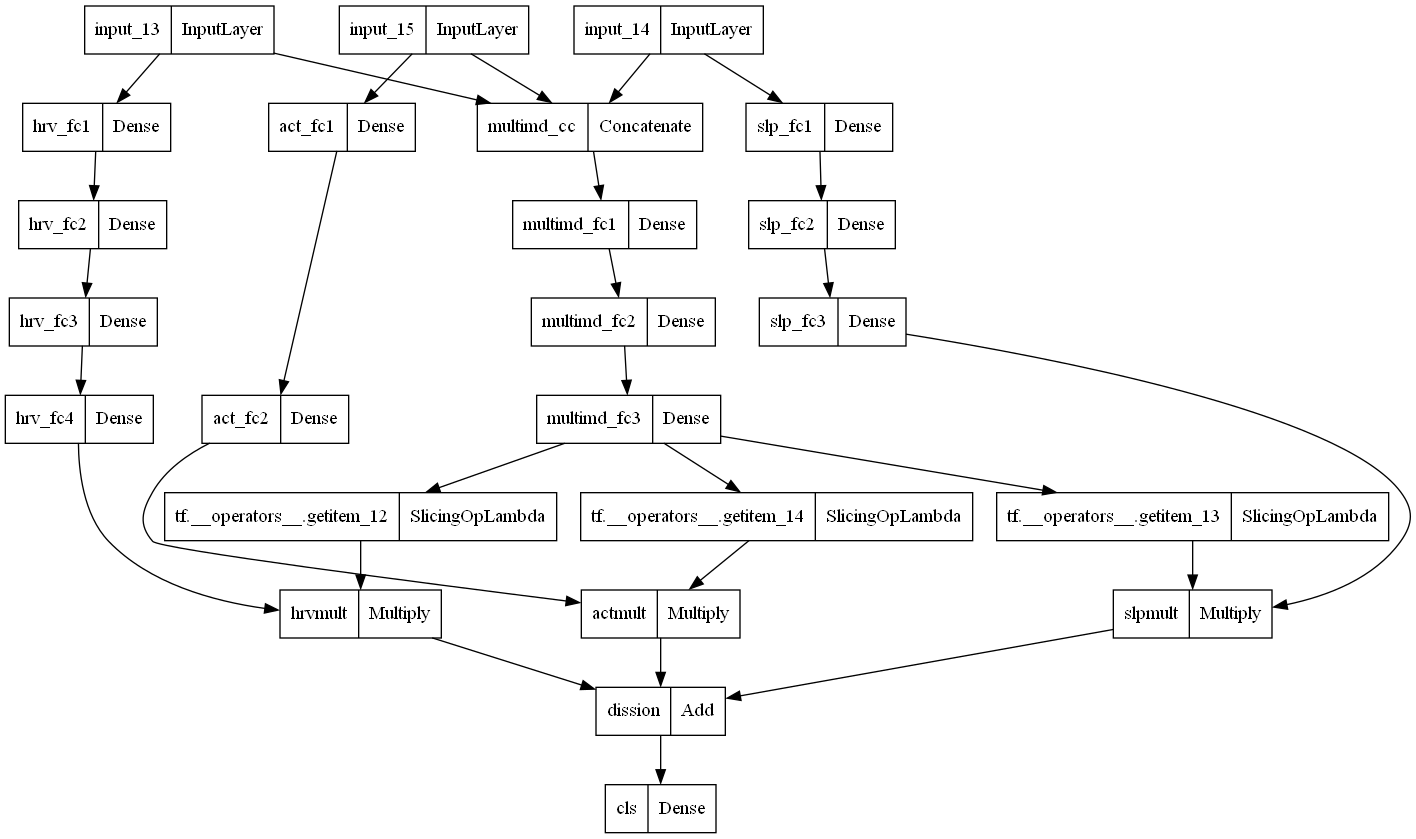

In [128]:
hrvmd = hrvcls()
slpmd = slpcls()
actmd = actcls()

tstmd = ppd_class_model(hrv_md=hrvmd,slp_md=slpmd,act_md=actmd)
print(tstmd.summary())
tf.keras.utils.plot_model(tstmd)

sub 5 : acc = 0.6667 in fold 74
sub 6 : acc = 0.9167 in fold 63
sub 8 : acc = 0.8571 in fold 43
sub 9 : acc = 0.925 in fold 63
sub 16 : acc = 0.6316 in fold 74
sub 18 : acc = 0.0 in fold 48
sub 20 : acc = 0.8 in fold 64
sub 24 : acc = 0.9167 in fold 63
sub 25 : acc = 1.0 in fold 67
sub 28 : acc = 0.7941 in fold 48
sub 29 : acc = 0.5556 in fold 48
sub 30 : acc = 0.6 in fold 69
sub 32 : acc = 0.4286 in fold 52
sub 33 : acc = 0.0 in fold 34
sub 35 : acc = 1.0 in fold 71
sub 37 : acc = 0.0 in fold 55
sub 41 : acc = 0.6875 in fold 59
sub 42 : acc = 0.4286 in fold 66
sub 44 : acc = 0.0 in fold 70
sub 53 : acc = 0.6667 in fold 42
sub 55 : acc = 0.9722 in fold 51
sub 58 : acc = 0.0 in fold 78
sub 60 : acc = 0.5385 in fold 61
sub 63 : acc = 0.6667 in fold 60
sub 66 : acc = 0.25 in fold 42
sub 67 : acc = 0.0 in fold 60
sub 69 : acc = 0.963 in fold 81
sub 70 : acc = 0.975 in fold 76
sub 72 : acc = 0.0 in fold 62
sub 75 : acc = 0.6 in fold 70
sub 80 : acc = 0.2963 in fold 64
sub 81 : acc = 1.0 in 

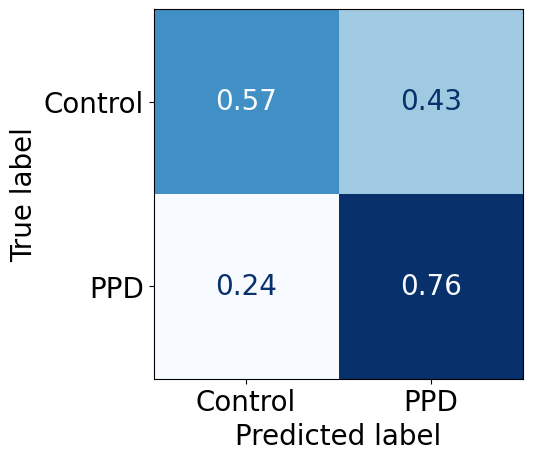

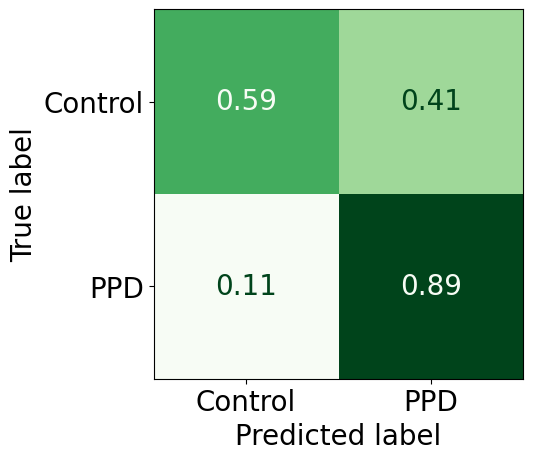

: 

In [ ]:
# PPD
tf.keras.utils.set_random_seed(42)
sgkf = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=42)

tt_res = np.array([])
tt_y = np.array([])
tt_subres = np.array([])
tt_suby = np.array([])

for sub in np.array([5,6,8,9,
                     16,18,
                     20,24,25,28,29,
                     30,32,33,35,37,
                     41,42,44,
                     53,55,58,
                     60,63,66,67,69,
                     70,72,75,
                     80,81,85,
                     90,91,92,93,95,98,99,
                     104]) :
    
    tr_x = nm_kfcv[ftmtrix[:,-2]!=sub,:38+14+6]
    tr_y = ftmtrix[ftmtrix[:,-2]!=sub,-1]
    tst_x = nm_kfcv[ftmtrix[:,-2]==sub,:38+14+6]
    tst_y = ftmtrix[ftmtrix[:,-2]==sub,-1]
    tt_y = np.append(tt_y,tst_y)
    tt_suby = np.append(tt_suby,tst_y[0])

    spw = compute_sample_weight(class_weight="balanced",y=tr_y)

    ytronehot = tf.keras.utils.to_categorical(y=tr_y,num_classes=2)
    ytsonehot = tf.keras.utils.to_categorical(y=tst_y,num_classes=2)

    hrvmd = hrvcls()
    hrvmd.load_weights(f'multimodel_sub_ann_res/kfold/ann_ppd_hrv_sub{sub}.validbest.h5')
    hrvmd.trainable = False
    slpmd = slpcls()
    slpmd.load_weights(f'multimodel_sub_ann_res/kfold/ann_ppd_slp_sub{sub}.validbest.h5')
    slpmd.trainable = False
    actmd = actcls()
    actmd.load_weights(f'multimodel_sub_ann_res/kfold/ann_ppd_act_sub{sub}.validbest.h5')
    actmd.trainable = False

    val_results = np.array([])
    for i, (train_index, test_index) in enumerate(sgkf.split(tr_x, tr_y, ftmtrix[ftmtrix[:,-2]!=sub,-2])):
        xtr,ytroh = tr_x[train_index,:], ytronehot[train_index,:]
        xcv,ycvoh = tr_x[test_index,:], ytronehot[test_index,:]
        spw_tr = compute_sample_weight(class_weight="balanced",y=tr_y[train_index])
        spw_cv = compute_sample_weight(class_weight="balanced",y=tr_y[test_index])
        
        ytr_lab = tr_y[train_index]
        alln = len(ytr_lab)
        negn = len(ytr_lab[ytr_lab==0])
        posn = len(ytr_lab[ytr_lab==1])
        
        bias = np.array([posn/alln,negn/alln])
        tf.keras.backend.clear_session()
        tstmd = ppd_class_model(hrv_md=hrvmd,slp_md=slpmd,act_md=actmd)
        subopt = tf.keras.optimizers.AdamW(learning_rate=5e-4,global_clipnorm=1.0)
        tstmd.compile(optimizer=subopt,loss=tf.keras.losses.CategoricalCrossentropy(),
                      metrics=['categorical_accuracy',tf.keras.metrics.F1Score(average='macro')],
                      weighted_metrics=['categorical_accuracy'])
        his = tstmd.fit(x=[xtr[:,:38],xtr[:,38:38+14],xtr[:,38+14:38+14+6]],y=ytroh,
                        batch_size=256,epochs=100,verbose=0,sample_weight=spw_tr,
                        validation_data=([xcv[:,:38],xcv[:,38:38+14],xcv[:,38+14:38+14+6]],ycvoh,spw_cv),validation_batch_size=256)
        val_acc = his.history['val_weighted_categorical_accuracy']
        epc = np.argmax(val_acc)+1
        val_results = np.append(val_results,epc)

    alln = len(tr_y)
    negn = len(tr_y[tr_y==0])
    posn = len(tr_y[tr_y==1])
    bias = np.array([posn/alln+0.1,negn/alln-0.1])

    avg_epc = round(np.mean(val_results))
    tf.keras.backend.clear_session()
    submd = ppd_class_model(hrv_md=hrvmd,slp_md=slpmd,act_md=actmd)
    subopt = tf.keras.optimizers.AdamW(learning_rate=5e-4,global_clipnorm=1.0)
    submd.compile(optimizer=subopt,loss=tf.keras.losses.CategoricalCrossentropy(),
                  metrics=['categorical_accuracy'])
    his = submd.fit(x=[tr_x[:,:38],tr_x[:,38:38+14],tr_x[:,38+14:38+14+6]],y=ytronehot,
                    batch_size=256,epochs=avg_epc,verbose=0,sample_weight=spw,
                    validation_data=([tst_x[:,:38],tst_x[:,38:38+14],tst_x[:,38+14:38+14+6]],ytsonehot),validation_batch_size=256)
    submd.save(f'multimodel_sub_ann_res/kfold/ann_ppd_sub{sub}.validbest.h5')
    ann_res = submd.predict([tst_x[:,:38],tst_x[:,38:38+14],tst_x[:,38+14:38+14+6]],batch_size=256,verbose=0)
    print(f"sub {sub} : acc = {round(accuracy_score(tst_y, ann_res.argmax(axis=1)),4)} in fold {avg_epc}" )
    tt_res = np.append(tt_res,ann_res.argmax(axis=1))
    if round(accuracy_score(tst_y, ann_res.argmax(axis=1)),4) >= 0.5 :
        tt_subres = np.append(tt_subres,tst_y[0])
    else:
        tt_subres = np.append(tt_subres,1-tst_y[0])

print(f"Macro-Avg : acc = {round(accuracy_score(tt_y, tt_res),4)}, balance_acc = {round(balanced_accuracy_score(tt_y, tt_res),4)}, Mf1 = {round(f1_score(tt_y, tt_res, average='macro'),4)}, AUC = {round(roc_auc_score(tt_y, tt_res),4)}" )
plt.rcParams.update({'font.size': 20})
cm3av2 = confusion_matrix(tt_y, tt_res,normalize='true')
cm_display3av2 = ConfusionMatrixDisplay(cm3av2,display_labels=['Control','PPD']).plot(cmap='Blues',colorbar=False)

print(f"Macro-Avg : acc = {round(accuracy_score(tt_suby, tt_subres),4)}, balance_acc = {round(balanced_accuracy_score(tt_suby, tt_subres),4)}, Mf1 = {round(f1_score(tt_suby, tt_subres, average='macro'),4)}, AUC = {round(roc_auc_score(tt_suby, tt_subres),4)}" )
plt.rcParams.update({'font.size': 20})
cm3av2 = confusion_matrix(tt_suby, tt_subres,normalize='true')
cm_display3av2 = ConfusionMatrixDisplay(cm3av2,display_labels=['Control','PPD']).plot(cmap='Greens',colorbar=False)

## Permutation test

In [11]:
def permutation_importance_keras(model:tf.keras.Model, X, y, sample_weight, metric='accuracy', n_repeats=10):
    baseline_score = model.evaluate(X, y, verbose=0, sample_weight=sample_weight)[-1]
    importances = np.zeros((X.shape[1], n_repeats))
    
    for i in range(X.shape[1]):
        for r in range(n_repeats):
            X_permuted = X.copy()
            # 打乱第 i 个特征
            np.random.shuffle(X_permuted[:, i])
            score = model.evaluate(X_permuted, y, verbose=0, sample_weight=sample_weight)[-1]
            importances[i, r] = baseline_score - score
    
    return {
        'importances_mean': importances.mean(axis=1),
        'importances_std': importances.std(axis=1)
    }

### HRV

In [12]:
tt_hrvtfimpmean = np.zeros((41,38))
tt_hrvtfimpstd = np.zeros((41,38))
s = 0
for sub in np.array([104,16,18,
                     20,24,25,28,29,
                     30,32,33,35,37,
                     41,42,44,
                     53,55,58,5,
                     60,63,66,67,69,6,
                     70,72,75,
                     80,81,85,8,
                     90,91,92,93,95,98,99,9]) :
    tf.keras.backend.clear_session()
    tstmd = hrvcls()
    subopt = tf.keras.optimizers.AdamW(learning_rate=1e-3,clipnorm=1.0)
    tstmd.compile(optimizer=subopt,loss=tf.keras.losses.CategoricalCrossentropy(),
                    metrics=['categorical_accuracy',tf.keras.metrics.F1Score(average='macro')],
                    weighted_metrics=['categorical_accuracy'])

    tstmd.load_weights(f'multimodel_sub_ann_res/kfold/ann_ppd_hrv_sub{sub}.validbest.h5')
    tst_x = nm_kfcv[:,:38]
    tst_y = ftmtrix[:,-1]
    spw = compute_sample_weight(class_weight="balanced",y=tst_y)
    ytsonehot = tf.keras.utils.to_categorical(y=tst_y,num_classes=2)
    result = permutation_importance_keras(tstmd, tst_x, ytsonehot, spw, n_repeats=25)
    tt_hrvtfimpmean[s,:] = np.round(result['importances_mean'],4)
    tt_hrvtfimpstd[s,:] = np.round(result['importances_std'],4)
    s = s+1


### Sleep

In [13]:
tt_slptfimpmean = np.zeros((41,14))
tt_slptfimpstd = np.zeros((41,14))
s = 0
for sub in np.array([104,16,18,
                     20,24,25,28,29,
                     30,32,33,35,37,
                     41,42,44,
                     53,55,58,5,
                     60,63,66,67,69,6,
                     70,72,75,
                     80,81,85,8,
                     90,91,92,93,95,98,99,9]) :
    tf.keras.backend.clear_session()
    tstmd = slpcls()
    subopt = tf.keras.optimizers.AdamW(learning_rate=1e-3,clipnorm=1.0)
    tstmd.compile(optimizer=subopt,loss=tf.keras.losses.CategoricalCrossentropy(),
                    metrics=['categorical_accuracy',tf.keras.metrics.F1Score(average='macro')],
                    weighted_metrics=['categorical_accuracy'])

    tstmd.load_weights(f'multimodel_sub_ann_res/kfold/ann_ppd_slp_sub{sub}.validbest.h5')
    tst_x = nm_kfcv[:,38:38+14]
    tst_y = ftmtrix[:,-1]
    spw = compute_sample_weight(class_weight="balanced",y=tst_y)
    ytsonehot = tf.keras.utils.to_categorical(y=tst_y,num_classes=2)
    result = permutation_importance_keras(tstmd, tst_x, ytsonehot, spw, n_repeats=25)
    tt_slptfimpmean[s,:] = np.round(result['importances_mean'],4)
    tt_slptfimpstd[s,:] = np.round(result['importances_std'],4)
    s = s+1


### Activity

In [14]:
tt_acttfimpmean = np.zeros((41,6))
tt_acttfimpstd = np.zeros((41,6))
s = 0
for sub in np.array([104,16,18,
                     20,24,25,28,29,
                     30,32,33,35,37,
                     41,42,44,
                     53,55,58,5,
                     60,63,66,67,69,6,
                     70,72,75,
                     80,81,85,8,
                     90,91,92,93,95,98,99,9]) :
    tf.keras.backend.clear_session()
    tstmd = actcls()
    subopt = tf.keras.optimizers.AdamW(learning_rate=1e-3,clipnorm=1.0)
    tstmd.compile(optimizer=subopt,loss=tf.keras.losses.CategoricalCrossentropy(),
                    metrics=['categorical_accuracy',tf.keras.metrics.F1Score(average='macro')],
                    weighted_metrics=['categorical_accuracy'])

    tstmd.load_weights(f'multimodel_sub_ann_res/kfold/ann_ppd_act_sub{sub}.validbest.h5')
    tst_x = nm_kfcv[:,38+14:38+14+6]
    tst_y = ftmtrix[:,-1]
    spw = compute_sample_weight(class_weight="balanced",y=tst_y)
    ytsonehot = tf.keras.utils.to_categorical(y=tst_y,num_classes=2)
    result = permutation_importance_keras(tstmd, tst_x, ytsonehot, spw, n_repeats=25)
    tt_acttfimpmean[s,:] = np.round(result['importances_mean'],4)
    tt_acttfimpstd[s,:] = np.round(result['importances_std'],4)
    s = s+1


### Multi-modality

In [17]:
def permutation_importance_mm(model:tf.keras.Model, X, y, sample_weight, metric='accuracy', n_repeats=10):
    baseline_score = model.evaluate([X[:,:38],X[:,38:38+14],X[:,38+14:38+14+6]], y, verbose=0, sample_weight=sample_weight)[-1]
    importances = np.zeros((X.shape[1], n_repeats))
    
    for i in range(X.shape[1]):
        for r in range(n_repeats):
            X_permuted = X.copy()
            # 打乱第 i 个特征
            np.random.shuffle(X_permuted[:, i])
            score = model.evaluate([X_permuted[:,:38],X_permuted[:,38:38+14],X_permuted[:,38+14:38+14+6]], y, verbose=0, sample_weight=sample_weight)[-1]
            importances[i, r] = baseline_score - score
    
    return {
        'importances_mean': importances.mean(axis=1),
        'importances_std': importances.std(axis=1)
    }

In [18]:
tt_mmtfimpmean = np.zeros((41,58))
tt_mmtfimpstd = np.zeros((41,58))
s = 0
for sub in np.array([104,16,18,
                     20,24,25,28,29,
                     30,32,33,35,37,
                     41,42,44,
                     53,55,58,5,
                     60,63,66,67,69,6,
                     70,72,75,
                     80,81,85,8,
                     90,91,92,93,95,98,99,9]) :

    hrvmd = hrvcls()
    hrvmd.load_weights(f'multimodel_sub_ann_res/kfold/ann_ppd_hrv_sub{sub}.validbest.h5')
    hrvmd.trainable = False
    slpmd = slpcls()
    slpmd.load_weights(f'multimodel_sub_ann_res/kfold/ann_ppd_slp_sub{sub}.validbest.h5')
    slpmd.trainable = False
    actmd = actcls()
    actmd.load_weights(f'multimodel_sub_ann_res/kfold/ann_ppd_act_sub{sub}.validbest.h5')
    actmd.trainable = False

    tstmd = ppd_class_model(hrv_md=hrvmd,slp_md=slpmd,act_md=actmd)
    subopt = tf.keras.optimizers.AdamW(learning_rate=1e-3,clipnorm=1.0)
    tstmd.compile(optimizer=subopt,loss=tf.keras.losses.CategoricalCrossentropy(),
                    metrics=['categorical_accuracy',tf.keras.metrics.F1Score(average='macro')],
                    weighted_metrics=['categorical_accuracy'])

    tstmd.load_weights(f'multimodel_sub_ann_res/kfold/ann_ppd_sub{sub}.validbest.h5')
    tst_x = nm_kfcv[:,:38+14+6]
    tst_y = ftmtrix[:,-1]
    spw = compute_sample_weight(class_weight="balanced",y=tst_y)
    ytsonehot = tf.keras.utils.to_categorical(y=tst_y,num_classes=2)
    result = permutation_importance_mm(tstmd, tst_x, ytsonehot, spw, n_repeats=25)
    tt_mmtfimpmean[s,:] = np.round(result['importances_mean'],4)
    tt_mmtfimpstd[s,:] = np.round(result['importances_std'],4)
    s = s+1


## Comperation model

### Subject Independent

#### SVM Classifier

sub 104 : acc = 1.0
sub 16 : acc = 0.6842
sub 18 : acc = 0.0
sub 20 : acc = 0.95
sub 24 : acc = 0.5833
sub 25 : acc = 1.0
sub 28 : acc = 0.9706
sub 29 : acc = 0.5556
sub 30 : acc = 0.72
sub 32 : acc = 1.0
sub 33 : acc = 0.5641
sub 35 : acc = 0.0
sub 37 : acc = 0.0
sub 41 : acc = 0.75
sub 42 : acc = 0.9429
sub 44 : acc = 0.5676
sub 53 : acc = 0.7333
sub 55 : acc = 0.9722
sub 58 : acc = 0.6667
sub 5 : acc = 0.6111
sub 60 : acc = 0.9231
sub 63 : acc = 0.6667
sub 66 : acc = 1.0
sub 67 : acc = 0.2162
sub 69 : acc = 0.8889
sub 6 : acc = 0.3333
sub 70 : acc = 0.975
sub 72 : acc = 0.8788
sub 75 : acc = 1.0
sub 80 : acc = 0.3704
sub 81 : acc = 0.8462
sub 85 : acc = 0.8
sub 8 : acc = 0.7143
sub 90 : acc = 0.8333
sub 91 : acc = 0.0
sub 92 : acc = 0.125
sub 93 : acc = 0.3448
sub 95 : acc = 0.55
sub 98 : acc = 0.5
sub 99 : acc = 0.1364
sub 9 : acc = 0.825
Macro-Avg : acc = 0.6923, balance_acc = 0.5914, Mf1 = 0.5532, AUC = 0.5914
Macro-Avg : acc = 0.7561, balance_acc = 0.6441, Mf1 = 0.6441, AUC = 0.

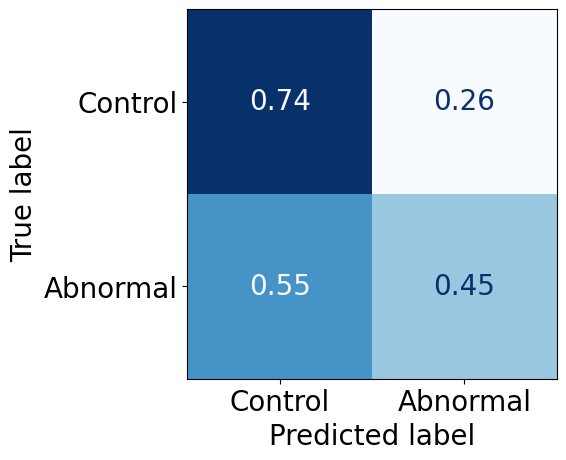

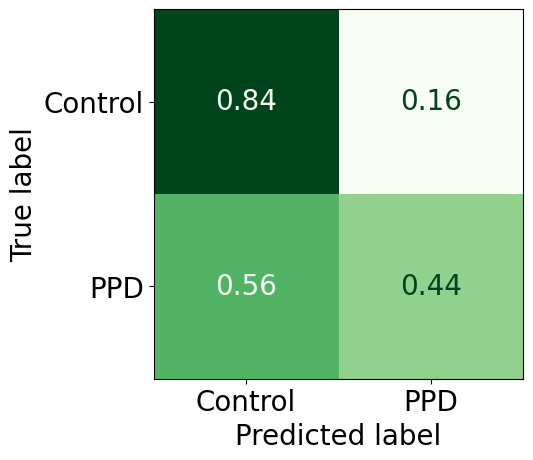

In [13]:
# SVM
tt_res = np.array([])
tt_y = np.array([])
tt_subres = np.array([])
tt_suby = np.array([])

for sub in np.array([104,16,18,
                     20,24,25,28,29,
                     30,32,33,35,37,
                     41,42,44,
                     53,55,58,5,
                     60,63,66,67,69,6,
                     70,72,75,
                     80,81,85,8,
                     90,91,92,93,95,98,99,9]) :
    tr_x = nm_kfcv[ftmtrix[:,-2]!=sub,:]
    tr_y = ftmtrix[ftmtrix[:,-2]!=sub,-1]
    tst_x = nm_kfcv[ftmtrix[:,-2]==sub,:]
    tst_y = ftmtrix[ftmtrix[:,-2]==sub,-1]
    tt_y = np.append(tt_y,tst_y)
    tt_suby = np.append(tt_suby,tst_y[0])

    svm_class = SVC(kernel='rbf',degree=3,class_weight='balanced',random_state=42)
    svm_class.fit(tr_x,tr_y)

    svm_res = svm_class.predict(tst_x)
    print(f"sub {sub} : acc = {round(accuracy_score(tst_y, svm_res),4)}" )
    tt_res = np.append(tt_res,svm_res)

    if round(accuracy_score(tst_y, svm_res),4) >= 0.5 :
        tt_subres = np.append(tt_subres,tst_y[0])
    else:
        tt_subres = np.append(tt_subres,1-tst_y[0])

print(f"Macro-Avg : acc = {round(accuracy_score(tt_y, tt_res),4)}, balance_acc = {round(balanced_accuracy_score(tt_y, tt_res),4)}, Mf1 = {round(f1_score(tt_y, tt_res, average='macro'),4)}, AUC = {round(roc_auc_score(tt_y, tt_res),4)}" )
plt.rcParams.update({'font.size': 20})
cm3av2 = confusion_matrix(tt_y, tt_res,normalize='true')
cm_display3av2 = ConfusionMatrixDisplay(cm3av2,display_labels=['Control','Abnormal']).plot(cmap='Blues',colorbar=False)

print(f"Macro-Avg : acc = {round(accuracy_score(tt_suby, tt_subres),4)}, balance_acc = {round(balanced_accuracy_score(tt_suby, tt_subres),4)}, Mf1 = {round(f1_score(tt_suby, tt_subres, average='macro'),4)}, AUC = {round(roc_auc_score(tt_suby, tt_subres),4)}" )
plt.rcParams.update({'font.size': 20})
cm3av2 = confusion_matrix(tt_suby, tt_subres,normalize='true')
cm_display3av2 = ConfusionMatrixDisplay(cm3av2,display_labels=['Control','PPD']).plot(cmap='Greens',colorbar=False)

sub 104 : acc = 0.8667
sub 16 : acc = 0.4737
sub 18 : acc = 0.0
sub 20 : acc = 0.95
sub 24 : acc = 0.9167
sub 25 : acc = 1.0
sub 28 : acc = 0.9706
sub 29 : acc = 0.2778
sub 30 : acc = 0.8
sub 32 : acc = 1.0
sub 33 : acc = 0.3077
sub 35 : acc = 0.3333
sub 37 : acc = 0.2727
sub 41 : acc = 0.75
sub 42 : acc = 0.9143
sub 44 : acc = 0.5946
sub 53 : acc = 0.8
sub 55 : acc = 0.9722
sub 58 : acc = 0.3333
sub 5 : acc = 0.4444
sub 60 : acc = 0.9231
sub 63 : acc = 0.6667
sub 66 : acc = 0.5
sub 67 : acc = 0.2162
sub 69 : acc = 0.7407
sub 6 : acc = 0.4167
sub 70 : acc = 0.95
sub 72 : acc = 0.7576
sub 75 : acc = 0.92
sub 80 : acc = 0.2593
sub 81 : acc = 0.7949
sub 85 : acc = 0.8
sub 8 : acc = 0.7143
sub 90 : acc = 0.8333
sub 91 : acc = 0.5
sub 92 : acc = 0.125
sub 93 : acc = 0.3448
sub 95 : acc = 0.7
sub 98 : acc = 0.5
sub 99 : acc = 0.1364
sub 9 : acc = 0.6
Macro-Avg : acc = 0.6471, balance_acc = 0.6184, Mf1 = 0.545, AUC = 0.6184
Macro-Avg : acc = 0.6585, balance_acc = 0.6215, Mf1 = 0.5876, AUC = 0

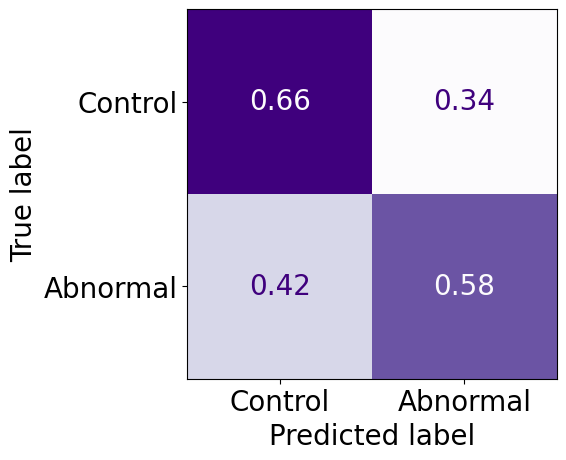

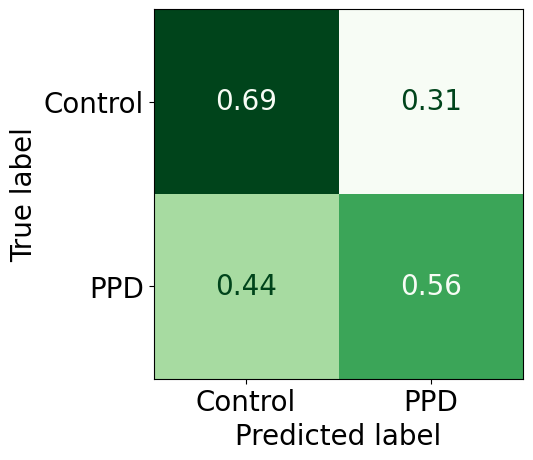

In [14]:
# SVM
tt_res = np.array([])
tt_y = np.array([])
tt_subres = np.array([])
tt_suby = np.array([])

for sub in np.array([104,16,18,
                     20,24,25,28,29,
                     30,32,33,35,37,
                     41,42,44,
                     53,55,58,5,
                     60,63,66,67,69,6,
                     70,72,75,
                     80,81,85,8,
                     90,91,92,93,95,98,99,9]) :
    tr_x = nm_kfcv[ftmtrix[:,-2]!=sub,:]
    tr_y = ftmtrix[ftmtrix[:,-2]!=sub,-1]
    tst_x = nm_kfcv[ftmtrix[:,-2]==sub,:]
    tst_y = ftmtrix[ftmtrix[:,-2]==sub,-1]
    tt_y = np.append(tt_y,tst_y)
    svm_class = SVC(kernel='rbf',degree=3,class_weight='balanced',random_state=42)
    tt_suby = np.append(tt_suby,tst_y[0])
        
    N0 = len(tr_y[tr_y==0])
    N1 = len(tr_y[tr_y==1])

    tr_x_0 = tr_x[tr_y==0,:]
    tr_x_1 = tr_x[tr_y==1,:]
    tr_y_0 = tr_y[tr_y==0]
    tr_y_1 = tr_y[tr_y==1]

    epoch = int(N0/N1) + 1

    kf = KFold(n_splits=epoch,shuffle=True,random_state=42)

    for fld, (_, val_idx) in enumerate(kf.split(tr_y_0)) :
        slct_x0 = tr_x_0[val_idx,:]
        slct_y0 = tr_y_0[val_idx]
        cc_trx = np.concatenate((slct_x0,tr_x_1),axis=0)
        cc_try = np.append(slct_y0,tr_y[tr_y==1])
        svm_class.fit(cc_trx,cc_try)

    svm_res = svm_class.predict(tst_x)
    print(f"sub {sub} : acc = {round(accuracy_score(tst_y, svm_res),4)}" )
    tt_res = np.append(tt_res,svm_res)
    
    if round(accuracy_score(tst_y, svm_res),4) >= 0.5 :
        tt_subres = np.append(tt_subres,tst_y[0])
    else:
        tt_subres = np.append(tt_subres,1-tst_y[0])

print(f"Macro-Avg : acc = {round(accuracy_score(tt_y, tt_res),4)}, balance_acc = {round(balanced_accuracy_score(tt_y, tt_res),4)}, Mf1 = {round(f1_score(tt_y, tt_res, average='macro'),4)}, AUC = {round(roc_auc_score(tt_y, tt_res),4)}" )
plt.rcParams.update({'font.size': 20})
cm3av2 = confusion_matrix(tt_y, tt_res,normalize='true')
cm_display3av2 = ConfusionMatrixDisplay(cm3av2,display_labels=['Control','Abnormal']).plot(cmap='Purples',colorbar=False)

print(f"Macro-Avg : acc = {round(accuracy_score(tt_suby, tt_subres),4)}, balance_acc = {round(balanced_accuracy_score(tt_suby, tt_subres),4)}, Mf1 = {round(f1_score(tt_suby, tt_subres, average='macro'),4)}, AUC = {round(roc_auc_score(tt_suby, tt_subres),4)}" )
plt.rcParams.update({'font.size': 20})
cm3av2 = confusion_matrix(tt_suby, tt_subres,normalize='true')
cm_display3av2 = ConfusionMatrixDisplay(cm3av2,display_labels=['Control','PPD']).plot(cmap='Greens',colorbar=False)

#### KNN Classifier

sub 104 : acc = 1.0
sub 16 : acc = 0.8421
sub 18 : acc = 1.0
sub 20 : acc = 1.0
sub 24 : acc = 0.1667
sub 25 : acc = 0.9444
sub 28 : acc = 1.0
sub 29 : acc = 0.8333
sub 30 : acc = 0.08
sub 32 : acc = 1.0
sub 33 : acc = 0.6667
sub 35 : acc = 0.0
sub 37 : acc = 0.0
sub 41 : acc = 0.875
sub 42 : acc = 1.0
sub 44 : acc = 0.973
sub 53 : acc = 0.8667
sub 55 : acc = 1.0
sub 58 : acc = 0.6667
sub 5 : acc = 0.9444
sub 60 : acc = 0.9231
sub 63 : acc = 0.6667
sub 66 : acc = 0.75
sub 67 : acc = 0.7027
sub 69 : acc = 0.963
sub 6 : acc = 0.0833
sub 70 : acc = 1.0
sub 72 : acc = 0.9394
sub 75 : acc = 1.0
sub 80 : acc = 0.7778
sub 81 : acc = 0.9744
sub 85 : acc = 1.0
sub 8 : acc = 1.0
sub 90 : acc = 0.0
sub 91 : acc = 0.0
sub 92 : acc = 0.7083
sub 93 : acc = 0.0345
sub 95 : acc = 0.15
sub 98 : acc = 1.0
sub 99 : acc = 0.7273
sub 9 : acc = 0.925
Macro-Avg : acc = 0.779, balance_acc = 0.4885, Mf1 = 0.4823, AUC = 0.4885
Macro-Avg : acc = 0.7805, balance_acc = 0.5, Mf1 = 0.4384, AUC = 0.5


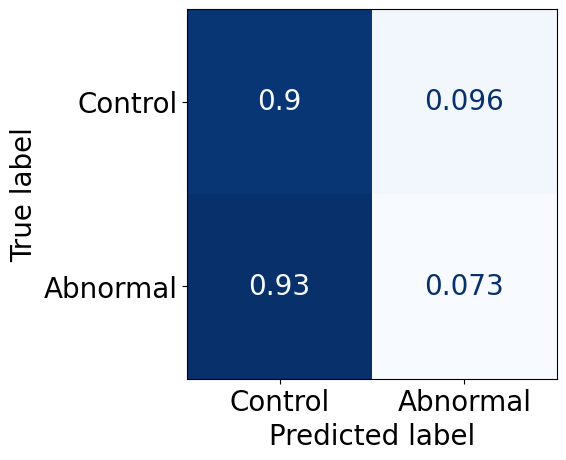

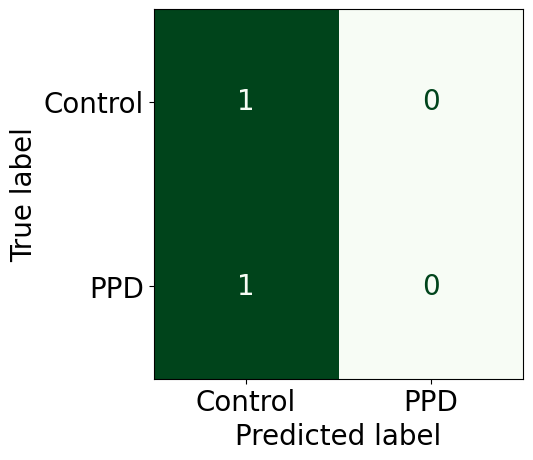

In [ ]:
# KNN
tt_res = np.array([])
tt_y = np.array([])
tt_subres = np.array([])
tt_suby = np.array([])

for sub in np.array([104,16,18,
                     20,24,25,28,29,
                     30,32,33,35,37,
                     41,42,44,
                     53,55,58,5,
                     60,63,66,67,69,6,
                     70,72,75,
                     80,81,85,8,
                     90,91,92,93,95,98,99,9]) :
    tr_x = nm_kfcv[ftmtrix[:,-2]!=sub,:]
    tr_y = ftmtrix[ftmtrix[:,-2]!=sub,-1]
    tst_x = nm_kfcv[ftmtrix[:,-2]==sub,:]
    tst_y = ftmtrix[ftmtrix[:,-2]==sub,-1]
    tt_y = np.append(tt_y,tst_y)
    tt_suby = np.append(tt_suby,tst_y[0])
    
    knn_class = KNeighborsClassifier(n_neighbors=5)
    knn_class.fit(tr_x,tr_y)

    knn_res = knn_class.predict(tst_x)
    print(f"sub {sub} : acc = {round(accuracy_score(tst_y, knn_res),4)}")
    tt_res = np.append(tt_res,knn_res)

    if round(accuracy_score(tst_y, knn_res),4) >= 0.5 :
        tt_subres = np.append(tt_subres,tst_y[0])
    else:
        tt_subres = np.append(tt_subres,1-tst_y[0])

print(f"Macro-Avg : acc = {round(accuracy_score(tt_y, tt_res),4)}, balance_acc = {round(balanced_accuracy_score(tt_y, tt_res),4)}, Mf1 = {round(f1_score(tt_y, tt_res, average='macro'),4)}, AUC = {round(roc_auc_score(tt_y, tt_res),4)}" )
plt.rcParams.update({'font.size': 20})
cm3av2 = confusion_matrix(tt_y, tt_res,normalize='true')
cm_display3av2 = ConfusionMatrixDisplay(cm3av2,display_labels=['Control','Abnormal']).plot(cmap='Blues',colorbar=False)

print(f"Macro-Avg : acc = {round(accuracy_score(tt_suby, tt_subres),4)}, balance_acc = {round(balanced_accuracy_score(tt_suby, tt_subres),4)}, Mf1 = {round(f1_score(tt_suby, tt_subres, average='macro'),4)}, AUC = {round(roc_auc_score(tt_suby, tt_subres),4)}" )
plt.rcParams.update({'font.size': 20})
cm3av2 = confusion_matrix(tt_suby, tt_subres,normalize='true')
cm_display3av2 = ConfusionMatrixDisplay(cm3av2,display_labels=['Control','PPD']).plot(cmap='Greens',colorbar=False)

sub 104 : acc = 0.7667
sub 16 : acc = 0.4211
sub 18 : acc = 0.0
sub 20 : acc = 0.9
sub 24 : acc = 0.6667
sub 25 : acc = 0.7778
sub 28 : acc = 0.9118
sub 29 : acc = 0.1667
sub 30 : acc = 0.68
sub 32 : acc = 1.0
sub 33 : acc = 0.2821
sub 35 : acc = 0.5
sub 37 : acc = 0.2727
sub 41 : acc = 0.6875
sub 42 : acc = 0.7714
sub 44 : acc = 0.5676
sub 53 : acc = 0.7333
sub 55 : acc = 0.9444
sub 58 : acc = 0.0
sub 5 : acc = 0.4444
sub 60 : acc = 0.6923
sub 63 : acc = 0.6667
sub 66 : acc = 0.5
sub 67 : acc = 0.1622
sub 69 : acc = 0.6667
sub 6 : acc = 0.5833
sub 70 : acc = 0.8
sub 72 : acc = 0.6364
sub 75 : acc = 0.92
sub 80 : acc = 0.2222
sub 81 : acc = 0.4103
sub 85 : acc = 0.8
sub 8 : acc = 0.7143
sub 90 : acc = 0.8333
sub 91 : acc = 1.0
sub 92 : acc = 0.1667
sub 93 : acc = 0.6897
sub 95 : acc = 0.65
sub 98 : acc = 0.5
sub 99 : acc = 0.4091
sub 9 : acc = 0.425
Macro-Avg : acc = 0.5861, balance_acc = 0.6059, Mf1 = 0.5093, AUC = 0.6059
Macro-Avg : acc = 0.6829, balance_acc = 0.7569, Mf1 = 0.6532, A

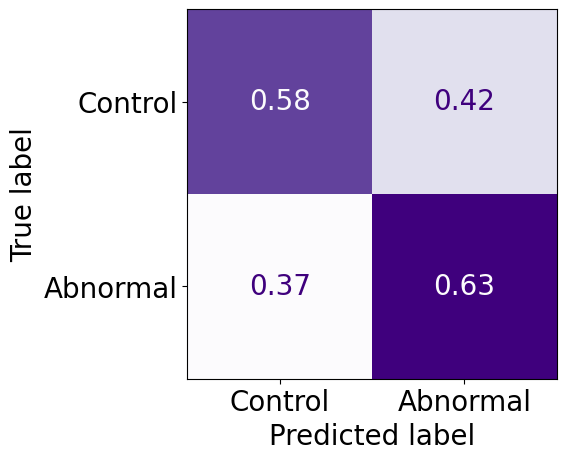

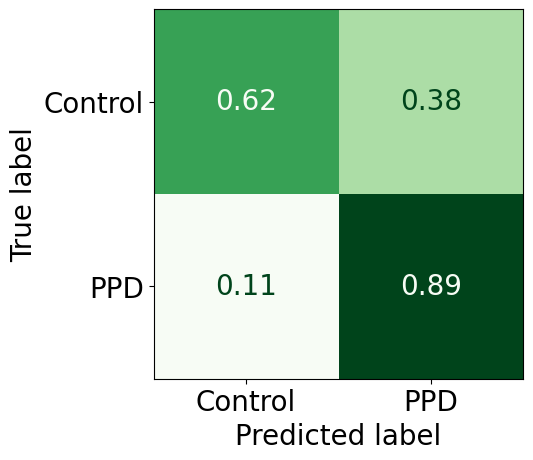

In [15]:
# KNN
tt_res = np.array([])
tt_y = np.array([])
tt_subres = np.array([])
tt_suby = np.array([])

for sub in np.array([104,16,18,
                     20,24,25,28,29,
                     30,32,33,35,37,
                     41,42,44,
                     53,55,58,5,
                     60,63,66,67,69,6,
                     70,72,75,
                     80,81,85,8,
                     90,91,92,93,95,98,99,9]) :
    tr_x = nm_kfcv[ftmtrix[:,-2]!=sub,:]
    tr_y = ftmtrix[ftmtrix[:,-2]!=sub,-1]
    tst_x = nm_kfcv[ftmtrix[:,-2]==sub,:]
    tst_y = ftmtrix[ftmtrix[:,-2]==sub,-1]
    tt_y = np.append(tt_y,tst_y)
    tt_suby = np.append(tt_suby,tst_y[0])
    
    knn_class = KNeighborsClassifier(n_neighbors=5)
    
    N0 = len(tr_y[tr_y==0])
    N1 = len(tr_y[tr_y==1])

    tr_x_0 = tr_x[tr_y==0,:]
    tr_x_1 = tr_x[tr_y==1,:]
    tr_y_0 = tr_y[tr_y==0]
    tr_y_1 = tr_y[tr_y==1]

    epoch = int(N0/N1) + 1

    kf = KFold(n_splits=epoch,shuffle=True,random_state=42)

    for fld, (_, val_idx) in enumerate(kf.split(tr_y_0)) :
        slct_x0 = tr_x_0[val_idx,:]
        slct_y0 = tr_y_0[val_idx]
        cc_trx = np.concatenate((slct_x0,tr_x_1),axis=0)
        cc_try = np.append(slct_y0,tr_y[tr_y==1])
        knn_class.fit(cc_trx,cc_try)

    knn_res = knn_class.predict(tst_x)
    print(f"sub {sub} : acc = {round(accuracy_score(tst_y, knn_res),4)}" )
    tt_res = np.append(tt_res,knn_res)

    if round(accuracy_score(tst_y, knn_res),4) >= 0.5 :
        tt_subres = np.append(tt_subres,tst_y[0])
    else:
        tt_subres = np.append(tt_subres,1-tst_y[0])

print(f"Macro-Avg : acc = {round(accuracy_score(tt_y, tt_res),4)}, balance_acc = {round(balanced_accuracy_score(tt_y, tt_res),4)}, Mf1 = {round(f1_score(tt_y, tt_res, average='macro'),4)}, AUC = {round(roc_auc_score(tt_y, tt_res),4)}" )
plt.rcParams.update({'font.size': 20})
cm3av2 = confusion_matrix(tt_y, tt_res,normalize='true')
cm_display3av2 = ConfusionMatrixDisplay(cm3av2,display_labels=['Control','Abnormal']).plot(cmap='Purples',colorbar=False)

print(f"Macro-Avg : acc = {round(accuracy_score(tt_suby, tt_subres),4)}, balance_acc = {round(balanced_accuracy_score(tt_suby, tt_subres),4)}, Mf1 = {round(f1_score(tt_suby, tt_subres, average='macro'),4)}, AUC = {round(roc_auc_score(tt_suby, tt_subres),4)}" )
plt.rcParams.update({'font.size': 20})
cm3av2 = confusion_matrix(tt_suby, tt_subres,normalize='true')
cm_display3av2 = ConfusionMatrixDisplay(cm3av2,display_labels=['Control','PPD']).plot(cmap='Greens',colorbar=False)

#### RF

sub 104 : acc = 1.0
sub 16 : acc = 1.0
sub 18 : acc = 1.0
sub 20 : acc = 1.0
sub 24 : acc = 0.0
sub 25 : acc = 1.0
sub 28 : acc = 1.0
sub 29 : acc = 0.9444
sub 30 : acc = 0.04
sub 32 : acc = 1.0
sub 33 : acc = 0.8974
sub 35 : acc = 0.0
sub 37 : acc = 0.0
sub 41 : acc = 1.0
sub 42 : acc = 1.0
sub 44 : acc = 0.7027
sub 53 : acc = 1.0
sub 55 : acc = 1.0
sub 58 : acc = 1.0
sub 5 : acc = 1.0
sub 60 : acc = 1.0
sub 63 : acc = 1.0
sub 66 : acc = 1.0
sub 67 : acc = 1.0
sub 69 : acc = 1.0
sub 6 : acc = 0.0
sub 70 : acc = 1.0
sub 72 : acc = 0.9697
sub 75 : acc = 1.0
sub 80 : acc = 0.963
sub 81 : acc = 1.0
sub 85 : acc = 1.0
sub 8 : acc = 1.0
sub 90 : acc = 0.0
sub 91 : acc = 0.0
sub 92 : acc = 0.7083
sub 93 : acc = 0.0345
sub 95 : acc = 0.05
sub 98 : acc = 1.0
sub 99 : acc = 0.8636
sub 9 : acc = 1.0
Macro-Avg : acc = 0.8193, balance_acc = 0.4921, Mf1 = 0.4696, AUC = 0.4921
Macro-Avg : acc = 0.7805, balance_acc = 0.5, Mf1 = 0.4384, AUC = 0.5


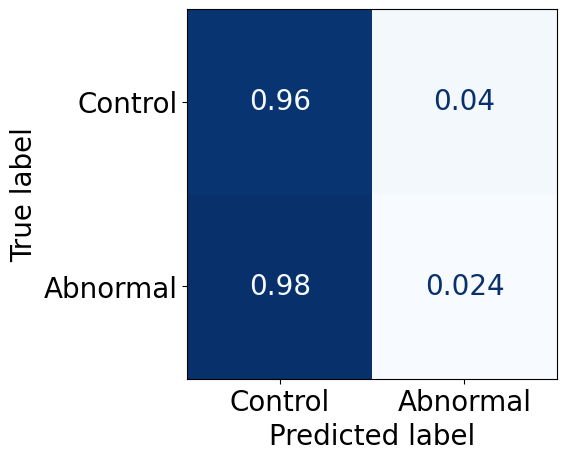

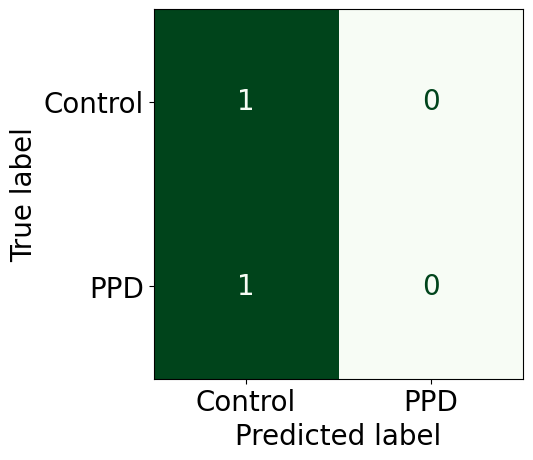

In [16]:
# RF
tt_res = np.array([])
tt_y = np.array([])
tt_subres = np.array([])
tt_suby = np.array([])

for sub in np.array([104,16,18,
                     20,24,25,28,29,
                     30,32,33,35,37,
                     41,42,44,
                     53,55,58,5,
                     60,63,66,67,69,6,
                     70,72,75,
                     80,81,85,8,
                     90,91,92,93,95,98,99,9]) :
    tr_x = nm_kfcv[ftmtrix[:,-2]!=sub,:]
    tr_y = ftmtrix[ftmtrix[:,-2]!=sub,-1]
    tst_x = nm_kfcv[ftmtrix[:,-2]==sub,:]
    tst_y = ftmtrix[ftmtrix[:,-2]==sub,-1]
    tt_y = np.append(tt_y,tst_y)
    tt_suby = np.append(tt_suby,tst_y[0])
    
    rf_class = RandomForestClassifier(n_estimators=100,random_state=42,class_weight='balanced_subsample')
    rf_class.fit(tr_x,tr_y)

    rf_res = rf_class.predict(tst_x)
    print(f"sub {sub} : acc = {round(accuracy_score(tst_y, rf_res),4)}")
    tt_res = np.append(tt_res,rf_res)
    
    if round(accuracy_score(tst_y, rf_res),4) >= 0.5 :
        tt_subres = np.append(tt_subres,tst_y[0])
    else:
        tt_subres = np.append(tt_subres,1-tst_y[0])

print(f"Macro-Avg : acc = {round(accuracy_score(tt_y, tt_res),4)}, balance_acc = {round(balanced_accuracy_score(tt_y, tt_res),4)}, Mf1 = {round(f1_score(tt_y, tt_res, average='macro'),4)}, AUC = {round(roc_auc_score(tt_y, tt_res),4)}" )
plt.rcParams.update({'font.size': 20})
cm3av2 = confusion_matrix(tt_y, tt_res,normalize='true')
cm_display3av2 = ConfusionMatrixDisplay(cm3av2,display_labels=['Control','Abnormal']).plot(cmap='Blues',colorbar=False)

print(f"Macro-Avg : acc = {round(accuracy_score(tt_suby, tt_subres),4)}, balance_acc = {round(balanced_accuracy_score(tt_suby, tt_subres),4)}, Mf1 = {round(f1_score(tt_suby, tt_subres, average='macro'),4)}, AUC = {round(roc_auc_score(tt_suby, tt_subres),4)}" )
plt.rcParams.update({'font.size': 20})
cm3av2 = confusion_matrix(tt_suby, tt_subres,normalize='true')
cm_display3av2 = ConfusionMatrixDisplay(cm3av2,display_labels=['Control','PPD']).plot(cmap='Greens',colorbar=False)

sub 104 : acc = 0.8
sub 16 : acc = 0.7368
sub 18 : acc = 0.0
sub 20 : acc = 0.95
sub 24 : acc = 0.75
sub 25 : acc = 1.0
sub 28 : acc = 0.9706
sub 29 : acc = 0.0556
sub 30 : acc = 0.88
sub 32 : acc = 1.0
sub 33 : acc = 0.1795
sub 35 : acc = 0.1667
sub 37 : acc = 0.2727
sub 41 : acc = 0.6875
sub 42 : acc = 0.9714
sub 44 : acc = 0.5135
sub 53 : acc = 0.8
sub 55 : acc = 0.9722
sub 58 : acc = 0.3333
sub 5 : acc = 0.2222
sub 60 : acc = 0.7692
sub 63 : acc = 1.0
sub 66 : acc = 0.0
sub 67 : acc = 0.2973
sub 69 : acc = 0.7037
sub 6 : acc = 0.4167
sub 70 : acc = 0.975
sub 72 : acc = 0.7879
sub 75 : acc = 0.88
sub 80 : acc = 0.2593
sub 81 : acc = 0.6154
sub 85 : acc = 1.0
sub 8 : acc = 0.5714
sub 90 : acc = 1.0
sub 91 : acc = 0.5
sub 92 : acc = 0.0
sub 93 : acc = 0.2414
sub 95 : acc = 0.6
sub 98 : acc = 0.5
sub 99 : acc = 0.0
sub 9 : acc = 0.5
Macro-Avg : acc = 0.6056, balance_acc = 0.5772, Mf1 = 0.5085, AUC = 0.5772
Macro-Avg : acc = 0.6585, balance_acc = 0.6215, Mf1 = 0.5876, AUC = 0.6215


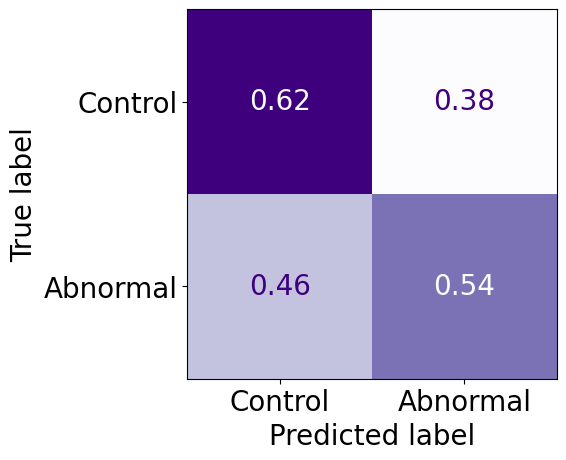

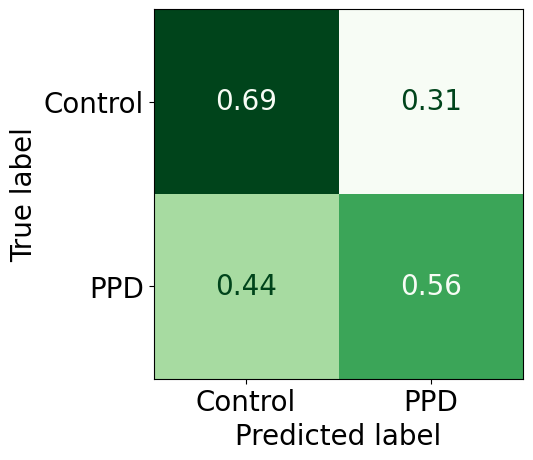

In [18]:
# RF
tt_res = np.array([])
tt_y = np.array([])
tt_subres = np.array([])
tt_suby = np.array([])

for sub in np.array([104,16,18,
                     20,24,25,28,29,
                     30,32,33,35,37,
                     41,42,44,
                     53,55,58,5,
                     60,63,66,67,69,6,
                     70,72,75,
                     80,81,85,8,
                     90,91,92,93,95,98,99,9]) :
    tr_x = nm_kfcv[ftmtrix[:,-2]!=sub,:]
    tr_y = ftmtrix[ftmtrix[:,-2]!=sub,-1]
    tst_x = nm_kfcv[ftmtrix[:,-2]==sub,:]
    tst_y = ftmtrix[ftmtrix[:,-2]==sub,-1]
    tt_y = np.append(tt_y,tst_y)
    tt_suby = np.append(tt_suby,tst_y[0])
    
    rf_class = RandomForestClassifier(n_estimators=100,random_state=42,class_weight='balanced_subsample')
    
    N0 = len(tr_y[tr_y==0])
    N1 = len(tr_y[tr_y==1])

    tr_x_0 = tr_x[tr_y==0,:]
    tr_x_1 = tr_x[tr_y==1,:]
    tr_y_0 = tr_y[tr_y==0]
    tr_y_1 = tr_y[tr_y==1]

    epoch = int(N0/N1) + 1

    kf = KFold(n_splits=epoch,shuffle=True,random_state=42)

    for fld, (_, val_idx) in enumerate(kf.split(tr_y_0)) :
        slct_x0 = tr_x_0[val_idx,:]
        slct_y0 = tr_y_0[val_idx]
        cc_trx = np.concatenate((slct_x0,tr_x_1),axis=0)
        cc_try = np.append(slct_y0,tr_y[tr_y==1])
        rf_class.fit(cc_trx,cc_try)

    rf_res = rf_class.predict(tst_x)
    print(f"sub {sub} : acc = {round(accuracy_score(tst_y, rf_res),4)}" )
    tt_res = np.append(tt_res,rf_res)

    if round(accuracy_score(tst_y, rf_res),4) >= 0.5 :
        tt_subres = np.append(tt_subres,tst_y[0])
    else:
        tt_subres = np.append(tt_subres,1-tst_y[0])

print(f"Macro-Avg : acc = {round(accuracy_score(tt_y, tt_res),4)}, balance_acc = {round(balanced_accuracy_score(tt_y, tt_res),4)}, Mf1 = {round(f1_score(tt_y, tt_res, average='macro'),4)}, AUC = {round(roc_auc_score(tt_y, tt_res),4)}" )
plt.rcParams.update({'font.size': 20})
cm3av2 = confusion_matrix(tt_y, tt_res,normalize='true')
cm_display3av2 = ConfusionMatrixDisplay(cm3av2,display_labels=['Control','Abnormal']).plot(cmap='Purples',colorbar=False)

print(f"Macro-Avg : acc = {round(accuracy_score(tt_suby, tt_subres),4)}, balance_acc = {round(balanced_accuracy_score(tt_suby, tt_subres),4)}, Mf1 = {round(f1_score(tt_suby, tt_subres, average='macro'),4)}, AUC = {round(roc_auc_score(tt_suby, tt_subres),4)}" )
plt.rcParams.update({'font.size': 20})
cm3av2 = confusion_matrix(tt_suby, tt_subres,normalize='true')
cm_display3av2 = ConfusionMatrixDisplay(cm3av2,display_labels=['Control','PPD']).plot(cmap='Greens',colorbar=False)

#### Adaboost

sub 104 : acc = 1.0
sub 16 : acc = 0.9474
sub 18 : acc = 0.0
sub 20 : acc = 1.0
sub 24 : acc = 0.25
sub 25 : acc = 1.0
sub 28 : acc = 1.0
sub 29 : acc = 0.7222
sub 30 : acc = 0.4
sub 32 : acc = 1.0
sub 33 : acc = 0.8718
sub 35 : acc = 0.0
sub 37 : acc = 0.0909
sub 41 : acc = 0.8125
sub 42 : acc = 1.0
sub 44 : acc = 0.9189
sub 53 : acc = 1.0
sub 55 : acc = 1.0
sub 58 : acc = 0.6667
sub 5 : acc = 0.9444
sub 60 : acc = 1.0
sub 63 : acc = 1.0
sub 66 : acc = 1.0
sub 67 : acc = 0.6486
sub 69 : acc = 0.963
sub 6 : acc = 0.1667
sub 70 : acc = 1.0
sub 72 : acc = 1.0
sub 75 : acc = 0.96
sub 80 : acc = 0.6667
sub 81 : acc = 0.8462
sub 85 : acc = 1.0
sub 8 : acc = 0.8571
sub 90 : acc = 0.3333
sub 91 : acc = 0.5
sub 92 : acc = 0.7083
sub 93 : acc = 0.3103
sub 95 : acc = 0.3
sub 98 : acc = 0.5
sub 99 : acc = 0.4545
sub 9 : acc = 0.95
Macro-Avg : acc = 0.7998, balance_acc = 0.5843, Mf1 = 0.5882, AUC = 0.5843
Macro-Avg : acc = 0.7561, balance_acc = 0.5243, Mf1 = 0.5119, AUC = 0.5243


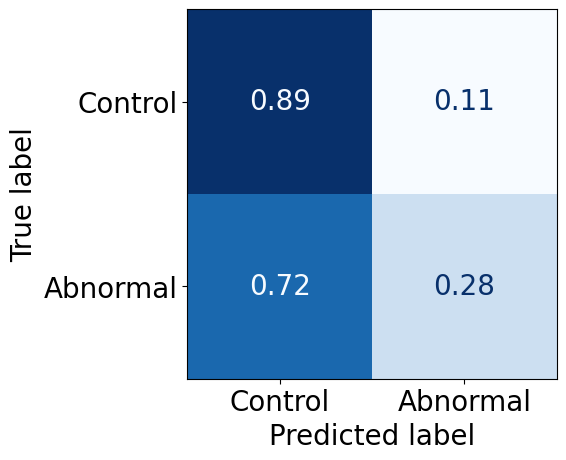

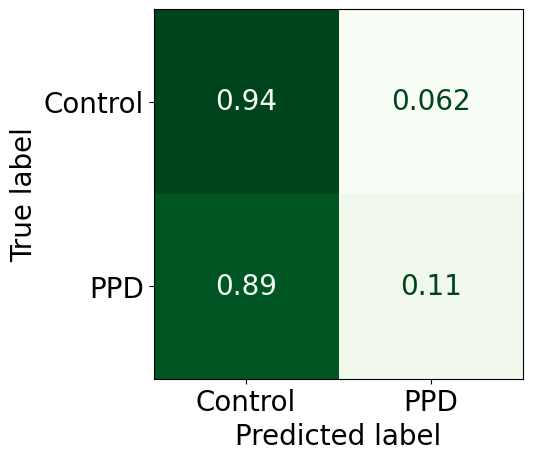

In [19]:
# RF
tt_res = np.array([])
tt_y = np.array([])
tt_subres = np.array([])
tt_suby = np.array([])

for sub in np.array([104,16,18,
                       20,24,25,28,29,
                       30,32,33,35,37,
                       41,42,44,
                       53,55,58,5,
                       60,63,66,67,69,6,
                       70,72,75,
                       80,81,85,8,
                       90,91,92,93,95,98,99,9]) :
    tr_x = nm_kfcv[ftmtrix[:,-2]!=sub,:]
    tr_y = ftmtrix[ftmtrix[:,-2]!=sub,-1]
    tst_x = nm_kfcv[ftmtrix[:,-2]==sub,:]
    tst_y = ftmtrix[ftmtrix[:,-2]==sub,-1]
    tt_y = np.append(tt_y,tst_y)
    tt_suby = np.append(tt_suby,tst_y[0])
    
    adb_class = AdaBoostClassifier(n_estimators=100,random_state=42)
    adb_class.fit(tr_x,tr_y)

    adb_res = adb_class.predict(tst_x)
    print(f"sub {sub} : acc = {round(accuracy_score(tst_y, adb_res),4)}")
    tt_res = np.append(tt_res,adb_res)

    if round(accuracy_score(tst_y, adb_res),4) >= 0.5 :
        tt_subres = np.append(tt_subres,tst_y[0])
    else:
        tt_subres = np.append(tt_subres,1-tst_y[0])

print(f"Macro-Avg : acc = {round(accuracy_score(tt_y, tt_res),4)}, balance_acc = {round(balanced_accuracy_score(tt_y, tt_res),4)}, Mf1 = {round(f1_score(tt_y, tt_res, average='macro'),4)}, AUC = {round(roc_auc_score(tt_y, tt_res),4)}" )
plt.rcParams.update({'font.size': 20})
cm3av2 = confusion_matrix(tt_y, tt_res,normalize='true')
cm_display3av2 = ConfusionMatrixDisplay(cm3av2,display_labels=['Control','Abnormal']).plot(cmap='Blues',colorbar=False)

print(f"Macro-Avg : acc = {round(accuracy_score(tt_suby, tt_subres),4)}, balance_acc = {round(balanced_accuracy_score(tt_suby, tt_subres),4)}, Mf1 = {round(f1_score(tt_suby, tt_subres, average='macro'),4)}, AUC = {round(roc_auc_score(tt_suby, tt_subres),4)}" )
plt.rcParams.update({'font.size': 20})
cm3av2 = confusion_matrix(tt_suby, tt_subres,normalize='true')
cm_display3av2 = ConfusionMatrixDisplay(cm3av2,display_labels=['Control','PPD']).plot(cmap='Greens',colorbar=False)

sub 104 : acc = 0.7333
sub 16 : acc = 0.7895
sub 18 : acc = 0.0
sub 20 : acc = 0.9
sub 24 : acc = 0.9167
sub 25 : acc = 0.6667
sub 28 : acc = 0.9706
sub 29 : acc = 0.5
sub 30 : acc = 0.92
sub 32 : acc = 1.0
sub 33 : acc = 0.6667
sub 35 : acc = 0.0
sub 37 : acc = 0.3636
sub 41 : acc = 0.625
sub 42 : acc = 0.8
sub 44 : acc = 0.4865
sub 53 : acc = 0.8667
sub 55 : acc = 0.8889
sub 58 : acc = 0.3333
sub 5 : acc = 0.3333
sub 60 : acc = 0.8462
sub 63 : acc = 0.6667
sub 66 : acc = 0.5
sub 67 : acc = 0.1892
sub 69 : acc = 0.5185
sub 6 : acc = 0.5
sub 70 : acc = 0.825
sub 72 : acc = 0.8485
sub 75 : acc = 0.92
sub 80 : acc = 0.3704
sub 81 : acc = 0.5385
sub 85 : acc = 0.8
sub 8 : acc = 0.7143
sub 90 : acc = 0.6667
sub 91 : acc = 0.5
sub 92 : acc = 0.1667
sub 93 : acc = 0.2414
sub 95 : acc = 0.75
sub 98 : acc = 0.5
sub 99 : acc = 0.1818
sub 9 : acc = 0.575
Macro-Avg : acc = 0.6264, balance_acc = 0.6061, Mf1 = 0.5299, AUC = 0.6061
Macro-Avg : acc = 0.7317, balance_acc = 0.7083, Mf1 = 0.6676, AUC = 

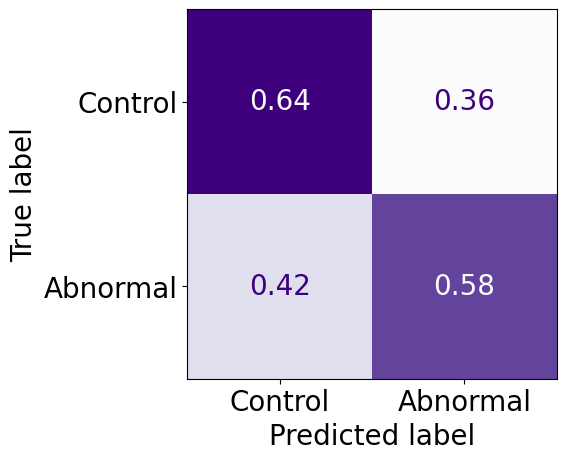

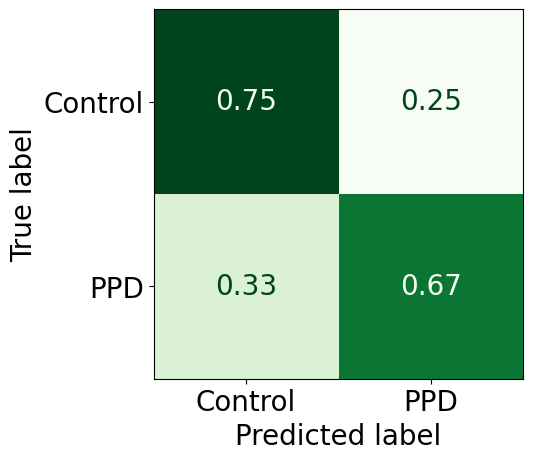

In [20]:
# RF
tt_res = np.array([])
tt_y = np.array([])
tt_subres = np.array([])
tt_suby = np.array([])

for sub in np.array([104,16,18,
                       20,24,25,28,29,
                       30,32,33,35,37,
                       41,42,44,
                       53,55,58,5,
                       60,63,66,67,69,6,
                       70,72,75,
                       80,81,85,8,
                       90,91,92,93,95,98,99,9]) :
    tr_x = nm_kfcv[ftmtrix[:,-2]!=sub,:]
    tr_y = ftmtrix[ftmtrix[:,-2]!=sub,-1]
    tst_x = nm_kfcv[ftmtrix[:,-2]==sub,:]
    tst_y = ftmtrix[ftmtrix[:,-2]==sub,-1]
    tt_y = np.append(tt_y,tst_y)
    tt_suby = np.append(tt_suby,tst_y[0])
    
    adb_class = AdaBoostClassifier(n_estimators=100,random_state=42)
    
    N0 = len(tr_y[tr_y==0])
    N1 = len(tr_y[tr_y==1])

    tr_x_0 = tr_x[tr_y==0,:]
    tr_x_1 = tr_x[tr_y==1,:]
    tr_y_0 = tr_y[tr_y==0]
    tr_y_1 = tr_y[tr_y==1]

    epoch = int(N0/N1) + 1

    kf = KFold(n_splits=epoch,shuffle=True,random_state=42)

    for fld, (_, val_idx) in enumerate(kf.split(tr_y_0)) :
        slct_x0 = tr_x_0[val_idx,:]
        slct_y0 = tr_y_0[val_idx]
        cc_trx = np.concatenate((slct_x0,tr_x_1),axis=0)
        cc_try = np.append(slct_y0,tr_y[tr_y==1])
        adb_class.fit(cc_trx,cc_try)

    adb_res = adb_class.predict(tst_x)
    print(f"sub {sub} : acc = {round(accuracy_score(tst_y, adb_res),4)}" )
    tt_res = np.append(tt_res,adb_res)

    if round(accuracy_score(tst_y, adb_res),4) >= 0.5 :
        tt_subres = np.append(tt_subres,tst_y[0])
    else:
        tt_subres = np.append(tt_subres,1-tst_y[0])

print(f"Macro-Avg : acc = {round(accuracy_score(tt_y, tt_res),4)}, balance_acc = {round(balanced_accuracy_score(tt_y, tt_res),4)}, Mf1 = {round(f1_score(tt_y, tt_res, average='macro'),4)}, AUC = {round(roc_auc_score(tt_y, tt_res),4)}" )
plt.rcParams.update({'font.size': 20})
cm3av2 = confusion_matrix(tt_y, tt_res,normalize='true')
cm_display3av2 = ConfusionMatrixDisplay(cm3av2,display_labels=['Control','Abnormal']).plot(cmap='Purples',colorbar=False)

print(f"Macro-Avg : acc = {round(accuracy_score(tt_suby, tt_subres),4)}, balance_acc = {round(balanced_accuracy_score(tt_suby, tt_subres),4)}, Mf1 = {round(f1_score(tt_suby, tt_subres, average='macro'),4)}, AUC = {round(roc_auc_score(tt_suby, tt_subres),4)}" )
plt.rcParams.update({'font.size': 20})
cm3av2 = confusion_matrix(tt_suby, tt_subres,normalize='true')
cm_display3av2 = ConfusionMatrixDisplay(cm3av2,display_labels=['Control','PPD']).plot(cmap='Greens',colorbar=False)

#### XGboost

sub 104 : acc = 1.0
sub 16 : acc = 0.9474
sub 18 : acc = 0.6667
sub 20 : acc = 1.0
sub 24 : acc = 0.0
sub 25 : acc = 1.0
sub 28 : acc = 1.0
sub 29 : acc = 0.7778
sub 30 : acc = 0.2
sub 32 : acc = 1.0
sub 33 : acc = 0.8718
sub 35 : acc = 0.1667
sub 37 : acc = 0.0
sub 41 : acc = 0.8125
sub 42 : acc = 0.9714
sub 44 : acc = 0.7568
sub 53 : acc = 1.0
sub 55 : acc = 1.0
sub 58 : acc = 0.6667
sub 5 : acc = 0.7778
sub 60 : acc = 1.0
sub 63 : acc = 1.0
sub 66 : acc = 1.0
sub 67 : acc = 0.7027
sub 69 : acc = 1.0
sub 6 : acc = 0.0
sub 70 : acc = 1.0
sub 72 : acc = 0.9697
sub 75 : acc = 1.0
sub 80 : acc = 0.9259
sub 81 : acc = 1.0
sub 85 : acc = 1.0
sub 8 : acc = 0.8571
sub 90 : acc = 0.3333
sub 91 : acc = 0.0
sub 92 : acc = 0.5833
sub 93 : acc = 0.1034
sub 95 : acc = 0.35
sub 98 : acc = 1.0
sub 99 : acc = 0.4091
sub 9 : acc = 0.95
Macro-Avg : acc = 0.7875, balance_acc = 0.5236, Mf1 = 0.5248, AUC = 0.5236
Macro-Avg : acc = 0.7561, balance_acc = 0.4844, Mf1 = 0.4306, AUC = 0.4844


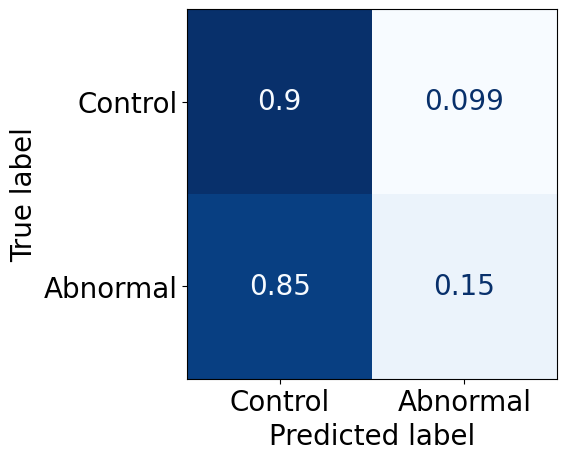

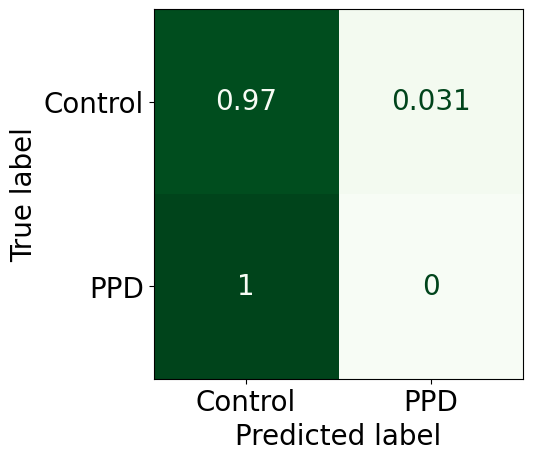

In [21]:
# RF
tt_res = np.array([])
tt_y = np.array([])
tt_subres = np.array([])
tt_suby = np.array([])

for sub in np.array([104,16,18,
                       20,24,25,28,29,
                       30,32,33,35,37,
                       41,42,44,
                       53,55,58,5,
                       60,63,66,67,69,6,
                       70,72,75,
                       80,81,85,8,
                       90,91,92,93,95,98,99,9]) :
    tr_x = nm_kfcv[ftmtrix[:,-2]!=sub,:]
    tr_y = ftmtrix[ftmtrix[:,-2]!=sub,-1]
    tst_x = nm_kfcv[ftmtrix[:,-2]==sub,:]
    tst_y = ftmtrix[ftmtrix[:,-2]==sub,-1]
    tt_y = np.append(tt_y,tst_y)
    tt_suby = np.append(tt_suby,tst_y[0])
    
    xgb_class = XGBClassifier(n_estimators=100,random_state=42,class_weight='balanced')
    xgb_class.fit(tr_x,tr_y)

    xgb_res = xgb_class.predict(tst_x)
    print(f"sub {sub} : acc = {round(accuracy_score(tst_y, xgb_res),4)}")
    tt_res = np.append(tt_res,xgb_res)

    if round(accuracy_score(tst_y, xgb_res),4) >= 0.5 :
        tt_subres = np.append(tt_subres,tst_y[0])
    else:
        tt_subres = np.append(tt_subres,1-tst_y[0])

print(f"Macro-Avg : acc = {round(accuracy_score(tt_y, tt_res),4)}, balance_acc = {round(balanced_accuracy_score(tt_y, tt_res),4)}, Mf1 = {round(f1_score(tt_y, tt_res, average='macro'),4)}, AUC = {round(roc_auc_score(tt_y, tt_res),4)}" )
plt.rcParams.update({'font.size': 20})
cm3av2 = confusion_matrix(tt_y, tt_res,normalize='true')
cm_display3av2 = ConfusionMatrixDisplay(cm3av2,display_labels=['Control','Abnormal']).plot(cmap='Blues',colorbar=False)

print(f"Macro-Avg : acc = {round(accuracy_score(tt_suby, tt_subres),4)}, balance_acc = {round(balanced_accuracy_score(tt_suby, tt_subres),4)}, Mf1 = {round(f1_score(tt_suby, tt_subres, average='macro'),4)}, AUC = {round(roc_auc_score(tt_suby, tt_subres),4)}" )
plt.rcParams.update({'font.size': 20})
cm3av2 = confusion_matrix(tt_suby, tt_subres,normalize='true')
cm_display3av2 = ConfusionMatrixDisplay(cm3av2,display_labels=['Control','PPD']).plot(cmap='Greens',colorbar=False)

sub 104 : acc = 0.8333
sub 16 : acc = 0.6316
sub 18 : acc = 0.0
sub 20 : acc = 0.95
sub 24 : acc = 0.9167
sub 25 : acc = 1.0
sub 28 : acc = 0.9412
sub 29 : acc = 0.1111
sub 30 : acc = 0.92
sub 32 : acc = 1.0
sub 33 : acc = 0.2308
sub 35 : acc = 0.1667
sub 37 : acc = 0.1818
sub 41 : acc = 0.5625
sub 42 : acc = 0.7429
sub 44 : acc = 0.4595
sub 53 : acc = 0.8
sub 55 : acc = 0.9722
sub 58 : acc = 0.3333
sub 5 : acc = 0.3889
sub 60 : acc = 0.8462
sub 63 : acc = 1.0
sub 66 : acc = 0.0
sub 67 : acc = 0.1081
sub 69 : acc = 0.6296
sub 6 : acc = 0.1667
sub 70 : acc = 0.875
sub 72 : acc = 0.7879
sub 75 : acc = 0.92
sub 80 : acc = 0.2593
sub 81 : acc = 0.6154
sub 85 : acc = 0.8
sub 8 : acc = 0.5714
sub 90 : acc = 1.0
sub 91 : acc = 0.5
sub 92 : acc = 0.0
sub 93 : acc = 0.4138
sub 95 : acc = 0.6
sub 98 : acc = 0.5
sub 99 : acc = 0.1364
sub 9 : acc = 0.6
Macro-Avg : acc = 0.5946, balance_acc = 0.5841, Mf1 = 0.5059, AUC = 0.5841
Macro-Avg : acc = 0.6341, balance_acc = 0.6059, Mf1 = 0.5684, AUC = 0.60

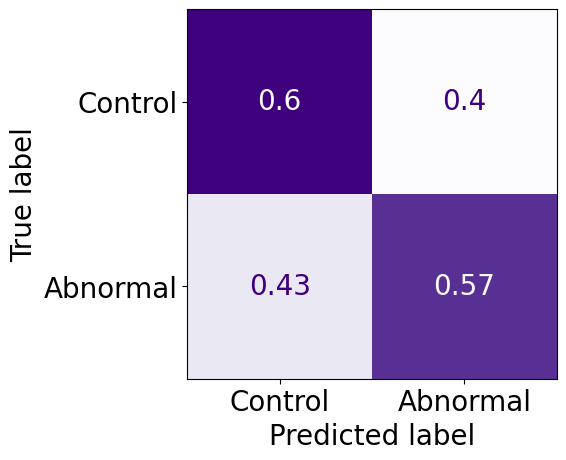

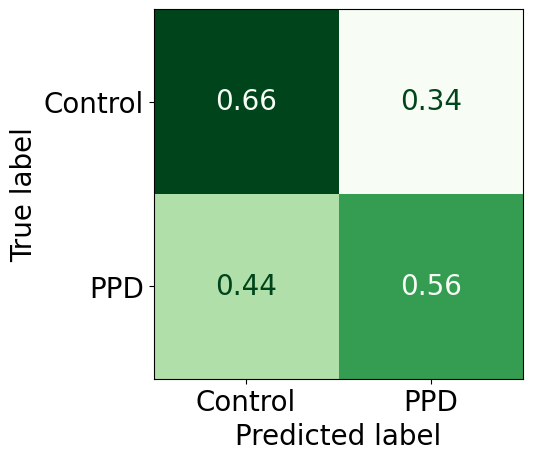

In [22]:
# RF
tt_res = np.array([])
tt_y = np.array([])
tt_subres = np.array([])
tt_suby = np.array([])

for sub in np.array([104,16,18,
                       20,24,25,28,29,
                       30,32,33,35,37,
                       41,42,44,
                       53,55,58,5,
                       60,63,66,67,69,6,
                       70,72,75,
                       80,81,85,8,
                       90,91,92,93,95,98,99,9]) :
    tr_x = nm_kfcv[ftmtrix[:,-2]!=sub,:]
    tr_y = ftmtrix[ftmtrix[:,-2]!=sub,-1]
    tst_x = nm_kfcv[ftmtrix[:,-2]==sub,:]
    tst_y = ftmtrix[ftmtrix[:,-2]==sub,-1]
    tt_y = np.append(tt_y,tst_y)
    tt_suby = np.append(tt_suby,tst_y[0])
    
    xgb_class = XGBClassifier(n_estimators=100,random_state=42,class_weight='balanced')
    
    N0 = len(tr_y[tr_y==0])
    N1 = len(tr_y[tr_y==1])

    tr_x_0 = tr_x[tr_y==0,:]
    tr_x_1 = tr_x[tr_y==1,:]
    tr_y_0 = tr_y[tr_y==0]
    tr_y_1 = tr_y[tr_y==1]

    epoch = int(N0/N1) + 1

    kf = KFold(n_splits=epoch,shuffle=True,random_state=42)

    for fld, (_, val_idx) in enumerate(kf.split(tr_y_0)) :
        slct_x0 = tr_x_0[val_idx,:]
        slct_y0 = tr_y_0[val_idx]
        cc_trx = np.concatenate((slct_x0,tr_x_1),axis=0)
        cc_try = np.append(slct_y0,tr_y[tr_y==1])
        xgb_class.fit(cc_trx,cc_try)

    xgb_res = xgb_class.predict(tst_x)
    print(f"sub {sub} : acc = {round(accuracy_score(tst_y, xgb_res),4)}" )
    tt_res = np.append(tt_res,xgb_res)

    if round(accuracy_score(tst_y, xgb_res),4) >= 0.5 :
        tt_subres = np.append(tt_subres,tst_y[0])
    else:
        tt_subres = np.append(tt_subres,1-tst_y[0])

print(f"Macro-Avg : acc = {round(accuracy_score(tt_y, tt_res),4)}, balance_acc = {round(balanced_accuracy_score(tt_y, tt_res),4)}, Mf1 = {round(f1_score(tt_y, tt_res, average='macro'),4)}, AUC = {round(roc_auc_score(tt_y, tt_res),4)}" )
plt.rcParams.update({'font.size': 20})
cm3av2 = confusion_matrix(tt_y, tt_res,normalize='true')
cm_display3av2 = ConfusionMatrixDisplay(cm3av2,display_labels=['Control','Abnormal']).plot(cmap='Purples',colorbar=False)

print(f"Macro-Avg : acc = {round(accuracy_score(tt_suby, tt_subres),4)}, balance_acc = {round(balanced_accuracy_score(tt_suby, tt_subres),4)}, Mf1 = {round(f1_score(tt_suby, tt_subres, average='macro'),4)}, AUC = {round(roc_auc_score(tt_suby, tt_subres),4)}" )
plt.rcParams.update({'font.size': 20})
cm3av2 = confusion_matrix(tt_suby, tt_subres,normalize='true')
cm_display3av2 = ConfusionMatrixDisplay(cm3av2,display_labels=['Control','PPD']).plot(cmap='Greens',colorbar=False)